# <center> Machine Learning in Computational Biology - Term Project </center>

## <center> Task D </center>
### <center> Explainability, Cell-to-Cell Communication, Error Analysis, Cell-Filtering Sensitivity & Patient-Effect Diagnostics </center>
---
#### **Instructor:** Prof. Elias Manolakos  
#### **MSc:** Data Science & Information Technologies 2025-2026
#### **Department:** Informatics & Telecommunications of the National & Kapodistrian University of Athens (NKUA)
---
**Paper of Choice:** Pinhasi, A., Yizhak, K. Uncovering gene and cellular signatures of immune checkpoint response via machine learning and single-cell RNA-seq. *npj Precision Oncology* 9, 95 (2025). https://doi.org/10.1038/s41698-025-00883-z

**Link:** https://www.nature.com/articles/s41698-025-00883-z

**Dataset Availability:** https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120575

---
## Task D Description

This notebook implements the `explainability, error analysis, cell-filtering sensitivity, and patient-effect diagnostics` proposed in our project. It jointly analyses the three final Task C pipelines:

- **Pathway representation:** PROGENy pathway scores with Logistic Regression.
- **Gene representation:** fold-specific HVG/MI-selected genes with XGBoost.
- **Cell-to-cell communication representation:** cell-specific sender-like and receiver-like ligand–receptor scores with the winning Task C classifier.

The notebook performs **no model selection or hyperparameter tuning**. Instead, it loads the exact fold-specific fitted models, scalers, held-out predictions, and feature sets exported by Task C. This preserves the Leave-One-Patient-Out (LOPO) validation design and ensures that Task D explains the same models used to report predictive performance.

The analysis proceeds as follows:

1. **Configuration** — Define Google Drive paths, runtime limits, output folders, and cell-filtering thresholds.
2. **Task C Import** — Load and validate separate pathway, gene, and cell-to-cell communication export bundles.
3. **Prediction Reconstruction** — Reconstruct held-out cell-, sample-, and patient-level prediction tables.
4. **SHAP Explainability** — Compute SHAP values on held-out cells in each LOPO fold.
5. **Global Feature Importance and Consistency** — Aggregate importance across all folds and quantify fold-level uncertainty and selection stability.
6. **SHAP Directionality** — Examine whether high or low feature values push predictions toward response or non-response.
7. **SHAP Dependence** — Visualise feature-value versus SHAP-contribution relationships.
8. **SHAP Interaction Analysis** — Aggregate TreeSHAP interactions for the gene and cell-to-cell tree models across eligible LOPO folds.
9. **Sample-Level Error Analysis** — Inspect ROC, Precision–Recall, and calibration curves.
10. **Confusion Matrix & Score Distribution** — Examine classifications at the descriptive 0.5 threshold.
11. **Misclassified Samples** — Identify false positives, false negatives, and uncertain samples.
12. **Cell-Level Distributions** — Assess within-sample prediction heterogeneity.
13. **Cell-Filtering Sensitivity** — Remove increasing fractions of low-confidence cells and recompute performance using patient-cluster bootstrap confidence intervals.
14. **Harmony Patient-Effect Diagnostic** — Quantify and visualise patient-associated structure before and after Harmony without changing the Task C models.
15. **Summary Export** — Save separate gene, pathway, cell-to-cell communication, and Harmony outputs without filename overwriting.
16. **Final Discussion** — State the correct interpretation and limitations of the analyses.

---
# 0. Configuration

This section defines the Google Drive location, the three Task C export filenames, the AnnData filename, runtime limits, and output folders. The runtime limits control `explainability speed and plot resolution only`; they do **not** alter the fitted Task C models, selected features, or held-out predictions.

The notebook searches common project locations recursively, so in most cases only `PROJECT_DIR_STRING` needs to be changed. Gene, pathway, cell-to-cell communication, and Harmony outputs receive separate filename prefixes to prevent accidental overwriting.

In [ ]:
# Required input filenames exported by Task C / produced by Task B.
PATHWAY_EXPORT_NAME = 'pathway_export_LR.pkl'
GENE_EXPORT_NAME = 'genes_export_XGBoost.pkl'
CELLTOCELL_EXPORT_NAME = 'ccc_export_RF.pkl'
ANNDATA_NAME = 'filtered_anndata_pathways.h5ad'

# Explainability and diagnostic settings.
SEED = 42
TOP_N_FEATURES = 15
N_DEPENDENCE_PLOTS = 6
STABLE_GENE_FREQUENCY = 0.75
MAX_SHAP_CELLS_PER_FOLD = 150
MAX_BACKGROUND_CELLS = 200
MAX_PLOT_POINTS_PER_FEATURE = 2500
MAX_INTERACTION_FEATURES = 8
MAX_INTERACTION_CELLS_PER_FOLD = 10
BOOTSTRAP_ITERS = 1000
RL_THRESHOLDS = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6]

---
# 1. Libraries

We import the scientific Python stack, the model libraries required to reconstruct the fitted Task C estimators, SHAP for model explainability, and Harmony for the optional patient-effect diagnostic.

The installation cell makes the notebook directly runnable in Google Colab. `xgboost` must be available before loading the pickle exports because the gene bundle contains fitted XGBoost estimator objects. Scikit-learn is pinned to the version used to create the exported estimators, including the cell-to-cell Random Forest.

In [3]:
%pip install -q "pandas==2.2.3" "scikit-learn==1.6.1" scanpy shap harmonypy xgboost seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 587.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 971.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 25.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pickle
import random
import re
import shutil
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

import scanpy as sc
import shap
import harmonypy as hm
import xgboost as xgb

from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
random.seed(SEED)
np.random.seed(SEED)

# Project layout: notebooks/, figures/, and outputs/ are sibling folders.
PROJECT_DIR = Path.cwd().parent
OUTPUT_DIR = PROJECT_DIR / 'outputs'
FIGURES_DIR = PROJECT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Output directory :', OUTPUT_DIR)
print('Figures directory:', FIGURES_DIR)
print('SHAP version     :', shap.__version__)
print('Scanpy version   :', sc.__version__)
print('XGBoost version  :', xgb.__version__)

Project directory: /content/drive/MyDrive
Output directory : /content/drive/MyDrive/TaskD_outputs
Figures directory: /content/drive/MyDrive/TaskD_figures
SHAP version     : 0.52.0
Scanpy version   : 1.12
XGBoost version  : 3.4.1


---
# 2. Load the Task C Export Bundles

Task C must provide three separate pickle files:

- `taskC_pathway_export.pkl` for the winning pathway pipeline.
- `taskC_gene_export.pkl` for the winning gene pipeline.
- `taskC_celltocell_export.pkl` for the winning cell-specific ligand–receptor communication pipeline.

Each bundle contains the selected feature set, model name, metrics, fold-specific fitted models, scalers, feature names, held-out cell probabilities, and aggregated sample/patient predictions. The validation checks below also detect if the exports were accidentally swapped or renamed incorrectly.

The AnnData object is loaded because it is required to reconstruct outer-training backgrounds for linear SHAP and to run the Harmony diagnostic. A compatibility copy is created only if a legacy PCA field prevents loading; the original file is never modified.

In [ ]:
def find_existing_file(filename):
    direct_candidates = [
        OUTPUT_DIR / filename,
        PROJECT_DIR / filename,
        Path.cwd() / filename,
    ]
    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    if PROJECT_DIR.exists():
        matches = list(PROJECT_DIR.rglob(filename))
        if matches:
            if len(matches) > 1:
                print(f'Warning: multiple matches for {filename}; using {matches[0]}')
            return matches[0]
    raise FileNotFoundError(
        f'Could not find {filename}. Place it under {OUTPUT_DIR}.'
    )


def load_pickle(path):
    with open(path, 'rb') as handle:
        return pickle.load(handle)


def validate_export(bundle, label):
    required = {
        'best_feature_set', 'best_model_name', 'metrics', 'fold_artifacts',
        'sample_results', 'patient_results'
    }
    missing = required - set(bundle)
    if missing:
        raise KeyError(f'{label} export is missing keys: {sorted(missing)}')
    if len(bundle['fold_artifacts']) == 0:
        raise ValueError(f'{label} export has no fold artifacts.')


def representation_label(tag):
    return {
        'pathway': 'Pathway',
        'gene': 'Gene',
        'celltocell': 'Cell-to-cell communication',
    }.get(str(tag), str(tag).title())


def read_h5ad_compat(path):
    try:
        return sc.read_h5ad(path)
    except Exception as first_error:
        temporary_path = OUTPUT_DIR / 'taskd_compatible_anndata.h5ad'
        shutil.copy2(path, temporary_path)
        with h5py.File(temporary_path, 'r+') as handle:
            legacy_key = 'uns/pca/params/mask_var'
            if legacy_key in handle:
                del handle[legacy_key]
            else:
                raise first_error
        print('Loaded a compatibility copy; the original AnnData file was not modified.')
        return sc.read_h5ad(temporary_path)


pathway_export_path = find_existing_file(PATHWAY_EXPORT_NAME)
gene_export_path = find_existing_file(GENE_EXPORT_NAME)
celltocell_export_path = find_existing_file(CELLTOCELL_EXPORT_NAME)
anndata_path = find_existing_file(ANNDATA_NAME)

pathway_bundle = load_pickle(pathway_export_path)
gene_bundle = load_pickle(gene_export_path)
celltocell_bundle = load_pickle(celltocell_export_path)
validate_export(pathway_bundle, 'Pathway')
validate_export(gene_bundle, 'Gene')
validate_export(celltocell_bundle, 'Cell-to-cell communication')

if 'pathway' not in str(pathway_bundle['best_feature_set']).lower():
    raise ValueError(
        'taskC_pathway_export.pkl does not contain a pathway feature set. '
        'Check that the Task C exports were renamed correctly.'
    )
if 'gene' not in str(gene_bundle['best_feature_set']).lower():
    raise ValueError(
        'taskC_gene_export.pkl does not contain a gene feature set. '
        'Check that the Task C exports were renamed correctly.'
    )

celltocell_feature_names = list(
    next(iter(celltocell_bundle['fold_artifacts'].values()))['feature_names']
)
if not celltocell_feature_names or not all(
    str(feature).startswith('CCC_') for feature in celltocell_feature_names
):
    raise ValueError(
        'taskC_celltocell_export.pkl does not contain the expected CCC features. '
        'Check that the Task C export was renamed correctly.'
    )

adata = read_h5ad_compat(anndata_path)
required_obs = {'patient_id', 'response_label', 'response', 'patient_timepoint'}
missing_obs = required_obs - set(adata.obs.columns)
if missing_obs:
    raise KeyError(f'AnnData is missing required metadata columns: {sorted(missing_obs)}')

print('Pathway pipeline:', pathway_bundle['best_feature_set'], '+', pathway_bundle['best_model_name'])
print('Pathway folds   :', len(pathway_bundle['fold_artifacts']))
print('Gene pipeline   :', gene_bundle['best_feature_set'], '+', gene_bundle['best_model_name'])
print('Gene folds      :', len(gene_bundle['fold_artifacts']))
print('Cell-to-cell pipeline:', celltocell_bundle['best_feature_set'], '+', celltocell_bundle['best_model_name'])
print('Cell-to-cell folds   :', len(celltocell_bundle['fold_artifacts']))
print('Cell-to-cell features:', len(celltocell_feature_names))
print('AnnData shape   :', adata.shape)
print('Patients        :', adata.obs['patient_id'].nunique())
print('Samples         :', adata.obs['patient_timepoint'].nunique())

/tmp/ipykernel_1695/2754348094.py:27: UserWarning: [18:33:45] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  return pickle.load(handle)


Pathway pipeline: pathways + LogisticRegression
Pathway folds   : 32
Gene pipeline   : mi_hvg_genes + XGBoost
Gene folds      : 32
Cell-to-cell pipeline: cells_cols + RandomForest
Cell-to-cell folds   : 32
Cell-to-cell features: 110
AnnData shape   : (16291, 10019)
Patients        : 32
Samples         : 48


**Comment:** Every result below is linked to one of the three `final Task C pipelines`. The pathway, gene, and cell-to-cell communication analyses remain separate even though they are presented in one notebook. This avoids mixing feature spaces and allows their predictive and biological interpretations to be compared without creating a combined feature ranking.

---
# 3. Reconstruct Held-Out Prediction Tables

Task C predicts individual cells and aggregates their probabilities to `biological samples`. Task D therefore retains two linked levels of analysis:

- **Cell-level predictions** are used to examine within-sample heterogeneity and cell-filtering sensitivity.
- **Sample-level predictions** are used for ROC, Precision–Recall, calibration, confusion matrices, and error analysis.

All probabilities come from the LOPO fold in which the corresponding patient was held out. No in-sample prediction is substituted during reconstruction.

In [6]:
def reconstruct_prediction_tables(bundle, tag):
    sample_results = bundle['sample_results'].copy()
    required = {'sample_id', 'patient_id', 'true_label', 'sample_score'}
    missing = required - set(sample_results.columns)
    if missing:
        raise KeyError(f'{tag} sample results are missing columns: {sorted(missing)}')

    sample_results['sample_id'] = sample_results['sample_id'].astype(str)
    sample_results['patient_id'] = sample_results['patient_id'].astype(str)
    sample_results['true_label'] = sample_results['true_label'].astype(int)
    sample_results['sample_score'] = sample_results['sample_score'].astype(float)
    sample_results['y_pred'] = (sample_results['sample_score'] >= 0.5).astype(int)
    sample_results['correct'] = sample_results['y_pred'] == sample_results['true_label']
    sample_results['error_type'] = np.select(
        [
            (sample_results['true_label'] == 0) & (sample_results['y_pred'] == 1),
            (sample_results['true_label'] == 1) & (sample_results['y_pred'] == 0),
        ],
        ['False positive', 'False negative'],
        default='Correct'
    )
    sample_results['confidence_margin'] = np.abs(sample_results['sample_score'] - 0.5)

    sample_label_map = sample_results.set_index('sample_id')['true_label'].to_dict()
    sample_patient_map = sample_results.set_index('sample_id')['patient_id'].to_dict()
    cell_frames = []
    for fold, artifact in bundle['fold_artifacts'].items():
        sample_ids = np.asarray(artifact['test_sample_ids']).astype(str)
        probabilities = np.asarray(artifact['cell_probs'], dtype=float)
        if len(sample_ids) != len(probabilities):
            raise ValueError(f'{tag}, fold {fold}: inconsistent held-out prediction lengths.')
        unknown = set(sample_ids) - set(sample_label_map)
        if unknown:
            raise KeyError(f'{tag}, fold {fold}: sample IDs missing from sample_results: {sorted(unknown)}')
        cell_frames.append(pd.DataFrame({
            'fold': int(fold),
            'held_patient': [sample_patient_map[sample_id] for sample_id in sample_ids],
            'patient_id': [sample_patient_map[sample_id] for sample_id in sample_ids],
            'sample_id': sample_ids,
            'true_label': [sample_label_map[sample_id] for sample_id in sample_ids],
            'cell_probability': probabilities,
            'cell_pred': (probabilities >= 0.5).astype(int),
        }))

    cell_predictions = pd.concat(cell_frames, ignore_index=True)
    if 'n_cells' not in sample_results.columns:
        counts = cell_predictions.groupby('sample_id').size().rename('n_cells')
        sample_results = sample_results.merge(counts, on='sample_id', how='left')

    patient_results = bundle['patient_results'].copy()
    sample_results.to_csv(OUTPUT_DIR / f'taskD_{tag}_sample_predictions.csv', index=False)
    cell_predictions.to_csv(OUTPUT_DIR / f'taskD_{tag}_cell_predictions.csv', index=False)

    print(f'{representation_label(tag)} cell-level predictions  : {cell_predictions.shape}')
    print(f'{representation_label(tag)} sample-level predictions: {sample_results.shape}')
    display(sample_results.head())
    return {
        'tag': tag,
        'sample_results': sample_results,
        'cell_predictions': cell_predictions,
        'patient_results': patient_results,
    }


pathway_predictions = reconstruct_prediction_tables(pathway_bundle, 'pathway')
gene_predictions = reconstruct_prediction_tables(gene_bundle, 'gene')
celltocell_predictions = reconstruct_prediction_tables(
    celltocell_bundle, 'celltocell'
)

Pathway cell-level predictions  : (16291, 7)
Pathway sample-level predictions: (48, 11)


,patient_id,sample_id,true_label,sample_score,n_cells,fold,mixed_patient,y_pred,correct,error_type,confidence_margin
0,P1,Post_P1,1,0.503274,291,1,True,1,True,Correct,0.003274
1,P1,Post_P1_2,0,0.524036,353,1,True,1,False,False positive,0.024036
2,P1,Pre_P1,1,0.509000,229,1,True,1,True,Correct,0.009000
3,P10,Post_P10,0,0.337330,396,2,False,0,True,Correct,0.162670
4,P11,Post_P11,0,0.447966,313,3,False,0,True,Correct,0.052034


Gene cell-level predictions  : (16291, 7)
Gene sample-level predictions: (48, 11)


,patient_id,sample_id,true_label,sample_score,n_cells,fold,mixed_patient,y_pred,correct,error_type,confidence_margin
0,P1,Post_P1,1,0.463451,291,1,True,0,False,False negative,0.036549
1,P1,Post_P1_2,0,0.483098,353,1,True,0,True,Correct,0.016902
2,P1,Pre_P1,1,0.493060,229,1,True,0,False,False negative,0.006940
3,P10,Post_P10,0,0.462106,396,2,False,0,True,Correct,0.037894
4,P11,Post_P11,0,0.496833,313,3,False,0,True,Correct,0.003167


Cell-to-cell communication cell-level predictions  : (16291, 7)
Cell-to-cell communication sample-level predictions: (48, 11)


,patient_id,sample_id,true_label,sample_score,n_cells,fold,mixed_patient,y_pred,correct,error_type,confidence_margin
0,P1,Post_P1,1,0.487105,291,1,True,0,False,False negative,0.012895
1,P1,Post_P1_2,0,0.389229,353,1,True,0,True,Correct,0.110771
2,P1,Pre_P1,1,0.424340,229,1,True,0,False,False negative,0.075660
3,P10,Post_P10,0,0.122694,396,2,False,0,True,Correct,0.377306
4,P11,Post_P11,0,0.286352,313,3,False,0,True,Correct,0.213648


---
# 4. SHAP and Model-Based Explainability

Predictive performance tells us `whether` a model separates responders from non-responders, but not `why`. SHAP values estimate the contribution of each feature to an individual prediction.

In this notebook:

- **Logistic Regression** uses `LinearExplainer`. Its background is reconstructed only from the corresponding outer-training patients, so the held-out patient does not define the SHAP reference distribution.
- **XGBoost and Random Forest** use `TreeExplainer` on a bounded sample of held-out cells from every LOPO fold.
- If SHAP fails for a fold, model-native coefficients or feature importances are retained as a transparent fallback.

The gene feature set can differ across folds because mutual-information selection is performed inside the validation process. Therefore, a missing gene is treated as `not selected in that fold`, not as missing data. The cell-to-cell features are directional communication proxies created in Task B: a sender-like score multiplies one cell's ligand expression by the sample-wide mean receptor expression, while a receiver-like score multiplies the sample-wide mean ligand expression by that cell's receptor expression. They estimate communication potential and do not identify a physical sender–receiver cell pair.

In [7]:
def balanced_indices(indices, group_values, max_total, rng):
    """Sample approximately equal numbers of rows per group."""
    indices = np.asarray(indices, dtype=int)
    group_values = np.asarray(group_values).astype(str)
    if len(indices) <= max_total:
        return indices

    groups = np.unique(group_values[indices])
    per_group = max(1, max_total // len(groups))
    selected = []
    for group in groups:
        candidates = indices[group_values[indices] == group]
        selected.extend(rng.choice(candidates, size=min(per_group, len(candidates)), replace=False))

    selected = np.asarray(selected, dtype=int)
    if len(selected) < max_total:
        remaining = np.setdiff1d(indices, selected, assume_unique=False)
        if len(remaining):
            extra = rng.choice(remaining, size=min(max_total - len(selected), len(remaining)), replace=False)
            selected = np.concatenate([selected, extra])
    return np.sort(selected[:max_total])


def raw_feature_matrix(adata_object, row_indices, feature_names):
    """Reconstruct a fold feature matrix in the exact exported feature order."""
    row_indices = np.asarray(row_indices, dtype=int)
    feature_names = list(feature_names)
    output = np.empty((len(row_indices), len(feature_names)), dtype=np.float32)

    gene_positions = []
    gene_names = []
    obs_positions = []
    obs_names = []

    var_set = set(adata_object.var_names.astype(str))
    obs_set = set(adata_object.obs.columns.astype(str))
    for position, feature in enumerate(feature_names):
        if feature in obs_set and feature.startswith('PROGENy_'):
            obs_positions.append(position)
            obs_names.append(feature)
        elif feature in var_set:
            gene_positions.append(position)
            gene_names.append(feature)
        else:
            raise KeyError(f'Feature {feature!r} is not present in AnnData.')

    if gene_names:
        gene_values = adata_object[row_indices, gene_names].X
        if sp.issparse(gene_values):
            gene_values = gene_values.toarray()
        output[:, gene_positions] = np.asarray(gene_values, dtype=np.float32)
    if obs_names:
        output[:, obs_positions] = adata_object.obs.iloc[row_indices][obs_names].to_numpy(dtype=np.float32)
    return output


def positive_class_shap_values(raw_values):
    """Return a cells × features matrix for the responder class."""
    if isinstance(raw_values, list):
        return np.asarray(raw_values[-1])
    values = np.asarray(raw_values)
    if values.ndim == 3:
        if values.shape[-1] == 2:
            return values[:, :, 1]
        if values.shape[0] == 2:
            return values[1]
        return values[:, :, -1]
    return values


def native_importance(model, feature_names):
    if hasattr(model, 'coef_'):
        return pd.Series(np.abs(np.ravel(model.coef_)), index=feature_names, dtype=float)
    if hasattr(model, 'feature_importances_'):
        return pd.Series(np.asarray(model.feature_importances_, dtype=float), index=feature_names)
    return pd.Series(np.nan, index=feature_names, dtype=float)


def compute_explainability(bundle, tag):
    """Compute held-out-cell SHAP values and fold-corrected global importance."""
    rng = np.random.default_rng(SEED)
    patient_values = adata.obs['patient_id'].astype(str).to_numpy()
    all_row_indices = np.arange(adata.n_obs)
    all_folds = sorted(int(fold) for fold in bundle['fold_artifacts'])

    importance_rows = []
    fold_records = []
    method_counts = {}

    for fold_key, artifact in bundle['fold_artifacts'].items():
        fold = int(fold_key)
        model = artifact['model']
        scaler = artifact['scaler']
        feature_names = list(artifact['feature_names'])
        X_test = np.asarray(artifact['Xte_transformed'])

        if X_test.shape[1] != len(feature_names):
            raise ValueError(f'Fold {fold}: feature-name and matrix dimensions do not match.')

        sample_idx = rng.choice(
            X_test.shape[0],
            size=min(MAX_SHAP_CELLS_PER_FOLD, X_test.shape[0]),
            replace=False,
        )
        X_sample = X_test[sample_idx]
        shap_values = None
        method = 'native_importance'

        try:
            if hasattr(model, 'coef_'):
                test_idx = np.asarray(artifact['test_idx'], dtype=int)
                train_idx = np.setdiff1d(all_row_indices, test_idx, assume_unique=False)
                bg_idx = balanced_indices(
                    train_idx,
                    patient_values,
                    MAX_BACKGROUND_CELLS,
                    rng,
                )
                X_background_raw = raw_feature_matrix(adata, bg_idx, feature_names)
                X_background = scaler.transform(X_background_raw)
                masker = shap.maskers.Independent(
                    X_background,
                    max_samples=X_background.shape[0],
                )
                explainer = shap.LinearExplainer(model, masker)
                shap_values = positive_class_shap_values(explainer.shap_values(X_sample))
                method = 'shap_linear_training_background'
            elif hasattr(model, 'feature_importances_'):
                explainer = shap.TreeExplainer(model)
                shap_values = positive_class_shap_values(explainer.shap_values(X_sample))
                method = 'shap_tree'
        except Exception as error:
            print(f'{tag}, fold {fold}: SHAP failed; using native importance. {type(error).__name__}: {error}')

        if shap_values is not None:
            shap_values = np.asarray(shap_values)
            if shap_values.ndim != 2 or shap_values.shape[1] != len(feature_names):
                print(f'{tag}, fold {fold}: unexpected SHAP dimensions; using native importance.')
                shap_values = None

        if shap_values is None:
            importance = native_importance(model, feature_names)
        else:
            importance = pd.Series(
                np.abs(shap_values).mean(axis=0),
                index=feature_names,
                dtype=float,
            )
            fold_records.append({
                'fold': fold,
                'held_patient': str(artifact.get('held_patient', fold)),
                'feature_names': feature_names,
                'X_sample': X_sample,
                'shap_values': shap_values,
            })

        method_counts[method] = method_counts.get(method, 0) + 1
        for feature, value in importance.items():
            if pd.notna(value):
                importance_rows.append({
                    'fold': fold,
                    'held_patient': str(artifact.get('held_patient', fold)),
                    'feature': feature,
                    'importance': float(value),
                    'method': method,
                })

    importance_df = pd.DataFrame(importance_rows)
    importance_df.to_csv(OUTPUT_DIR / f'taskD_{tag}_fold_feature_importance.csv', index=False)

    # Missing gene features indicate non-selection in that fold and receive zero
    # for the overall LOPO importance. Conditional importance is also retained.
    wide = importance_df.pivot_table(
        index='feature', columns='fold', values='importance', aggfunc='mean'
    ).reindex(columns=all_folds)
    selected = wide.notna()
    zero_filled = wide.fillna(0.0)

    summary = pd.DataFrame({
        'feature': wide.index,
        'overall_mean_importance': zero_filled.mean(axis=1).to_numpy(),
        'overall_std_importance': zero_filled.std(axis=1, ddof=1).fillna(0).to_numpy(),
        'conditional_mean_importance': wide.mean(axis=1, skipna=True).to_numpy(),
        'n_folds_selected': selected.sum(axis=1).to_numpy(dtype=int),
        'selection_frequency': selected.mean(axis=1).to_numpy(),
    })
    summary['overall_sem_importance'] = (
        summary['overall_std_importance'] / np.sqrt(len(all_folds))
    )
    summary['cv_importance_all_folds'] = (
        summary['overall_std_importance']
        / summary['overall_mean_importance'].replace(0, np.nan)
    )
    summary['feature_type'] = np.select(
        [
            summary['feature'].str.startswith('PROGENy_'),
            summary['feature'].str.startswith('CCC_'),
        ],
        ['Pathway', 'Cell-to-cell communication'],
        default='Gene',
    )
    summary = summary.sort_values(
        ['overall_mean_importance', 'selection_frequency'], ascending=[False, False]
    ).reset_index(drop=True)
    summary.to_csv(OUTPUT_DIR / f'taskD_{tag}_global_importance_corrected.csv', index=False)

    print(f'{tag}: methods={method_counts}; folds={len(all_folds)}; features={len(summary)}')
    return {
        'tag': tag,
        'importance_df': importance_df,
        'summary': summary,
        'fold_records': fold_records,
        'n_folds': len(all_folds),
        'method_counts': method_counts,
    }


pathway_explanations = compute_explainability(pathway_bundle, 'pathway')
gene_explanations = compute_explainability(gene_bundle, 'gene')
celltocell_explanations = compute_explainability(
    celltocell_bundle, 'celltocell'
)


def collect_feature_points(explanation_result, features):
    rows = []
    feature_set = set(features)
    for record in explanation_result['fold_records']:
        positions = {
            feature: record['feature_names'].index(feature)
            for feature in feature_set
            if feature in record['feature_names']
        }
        for feature, position in positions.items():
            for x_value, shap_value in zip(
                record['X_sample'][:, position],
                record['shap_values'][:, position],
            ):
                rows.append({
                    'feature': feature,
                    'feature_value_scaled': float(x_value),
                    'shap_value': float(shap_value),
                    'fold': record['fold'],
                    'held_patient': record['held_patient'],
                })
    return pd.DataFrame(rows)


def plot_global_importance(explanation_result):
    tag = explanation_result['tag']
    summary = explanation_result['summary']
    top = summary.head(TOP_N_FEATURES).sort_values('overall_mean_importance')

    fig, ax = plt.subplots(figsize=(8.5, max(5, 0.38 * len(top))))
    ax.barh(
        top['feature'],
        top['overall_mean_importance'],
        xerr=top['overall_sem_importance'],
        capsize=3,
        alpha=0.85,
    )
    ax.set_xlabel('Mean |SHAP| across all LOPO folds')
    ax.set_ylabel('Feature')
    ax.set_title(f'{representation_label(tag)} global importance\nmissing-fold importance = 0; error bars = SEM')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'taskD_{tag}_global_importance_corrected.png', dpi=180, bbox_inches='tight')
    plt.show()

    if tag == 'gene':
        plot_df = summary.head(max(TOP_N_FEATURES, 25))
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
        ax.scatter(
            plot_df['selection_frequency'],
            plot_df['overall_mean_importance'],
            s=55,
            alpha=0.8,
        )
        for _, row in plot_df.head(TOP_N_FEATURES).iterrows():
            ax.text(row['selection_frequency'], row['overall_mean_importance'], row['feature'], fontsize=8)
        ax.axvline(STABLE_GENE_FREQUENCY, color='red', linestyle='--', linewidth=1,
                   label=f'Stable threshold = {STABLE_GENE_FREQUENCY:.0%}')
        ax.set_xlabel('Selection frequency across LOPO folds')
        ax.set_ylabel('Mean |SHAP| across all folds')
        ax.set_title('Gene importance versus selection stability')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'taskD_gene_importance_vs_selection_frequency.png', dpi=180, bbox_inches='tight')
        plt.show()


def plot_beeswarm_like(explanation_result):
    tag = explanation_result['tag']
    summary = explanation_result['summary']
    top_features = summary.head(TOP_N_FEATURES)['feature'].tolist()
    points = collect_feature_points(explanation_result, top_features)
    points.to_csv(OUTPUT_DIR / f'taskD_{tag}_top_feature_shap_points.csv', index=False)

    if points.empty:
        print(f'{tag}: no SHAP values available for directionality plot.')
        return points

    rng = np.random.default_rng(SEED)
    pieces = []
    for feature, group in points.groupby('feature'):
        if len(group) > MAX_PLOT_POINTS_PER_FEATURE:
            group = group.sample(MAX_PLOT_POINTS_PER_FEATURE, random_state=SEED)
        pieces.append(group)
    plot_df = pd.concat(pieces, ignore_index=True)

    order = list(reversed(top_features))
    y_lookup = {feature: index for index, feature in enumerate(order)}
    y_values = plot_df['feature'].map(y_lookup).to_numpy(dtype=float)
    y_values += rng.normal(0, 0.10, size=len(y_values))

    color_values = plot_df['feature_value_scaled'].clip(-2.5, 2.5)
    norm = Normalize(vmin=-2.5, vmax=2.5)
    fig, ax = plt.subplots(figsize=(9, max(5.5, 0.38 * len(order))))
    scatter = ax.scatter(
        plot_df['shap_value'], y_values,
        c=color_values, cmap='coolwarm', norm=norm,
        s=9, alpha=0.55, linewidth=0,
    )
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel('SHAP value (positive → responder prediction)')
    ax.set_ylabel('Feature')
    ax.set_title(f'{representation_label(tag)} SHAP directionality on held-out cells')
    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label('Fold-standardized feature value')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'taskD_{tag}_shap_directionality.png', dpi=180, bbox_inches='tight')
    plt.show()
    return points


def dependence_and_direction_summary(explanation_result, points):
    tag = explanation_result['tag']
    summary = explanation_result['summary']

    if tag == 'gene':
        candidates = summary[summary['selection_frequency'] >= STABLE_GENE_FREQUENCY]
    else:
        candidates = summary
    features = candidates.head(N_DEPENDENCE_PLOTS)['feature'].tolist()

    direction_rows = []
    for feature in features:
        data = points[points['feature'] == feature].copy()
        if data.empty:
            data = collect_feature_points(explanation_result, [feature])
        if data.empty:
            continue

        rho, p_value = spearmanr(data['feature_value_scaled'], data['shap_value'])
        if rho > 0.05:
            direction = 'Higher value tends toward responder prediction'
        elif rho < -0.05:
            direction = 'Higher value tends toward non-responder prediction'
        else:
            direction = 'Weak or non-monotonic direction'

        direction_rows.append({
            'feature': feature,
            'spearman_rho_feature_vs_shap': float(rho),
            'p_value_descriptive_only': float(p_value),
            'direction': direction,
            'n_points': len(data),
            'n_folds_with_shap': data['fold'].nunique(),
        })

        fig, ax = plt.subplots(figsize=(6.8, 4.8))
        ax.scatter(data['feature_value_scaled'], data['shap_value'], s=14, alpha=0.35, linewidth=0)

        # Quantile-binned mean trend avoids implying a parametric relationship.
        try:
            data['bin'] = pd.qcut(data['feature_value_scaled'], q=12, duplicates='drop')
            trend = data.groupby('bin', observed=True).agg(
                x=('feature_value_scaled', 'mean'),
                y=('shap_value', 'mean'),
            )
            ax.plot(trend['x'], trend['y'], color='black', marker='o', linewidth=2,
                    markersize=4, label='Quantile-binned mean')
            ax.legend(fontsize=8)
        except Exception:
            pass

        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel(f'{feature} value (fold-standardized)')
        ax.set_ylabel(f'SHAP value for {feature}')
        ax.set_title(f'SHAP dependence: {feature}\n{data["fold"].nunique()} LOPO folds represented')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        safe_feature = ''.join(character if character.isalnum() or character in '-_' else '_'
                               for character in feature)
        plt.savefig(FIGURES_DIR / f'taskD_{tag}_dependence_{safe_feature}.png', dpi=180, bbox_inches='tight')
        plt.show()

    direction_df = pd.DataFrame(direction_rows)
    direction_df.to_csv(OUTPUT_DIR / f'taskD_{tag}_directionality_summary.csv', index=False)
    display(direction_df)
    return direction_df

pathway: methods={'shap_linear_training_background': 32}; folds=32; features=14
gene: methods={'shap_tree': 32}; folds=32; features=1141
celltocell: methods={'shap_tree': 32}; folds=32; features=110


---
# 5. Global Feature Importance and Consistency Across LOPO Folds

Global importance is calculated as the mean absolute SHAP value across all held-out-patient folds. Error bars show the standard error of the fold-level importance estimates.

The stability measure depends on the representation:

- **Genes:** the feature set may change between folds because selection is performed inside LOPO validation. Gene importance is therefore compared with selection frequency. A non-selected gene receives zero importance for that fold.
- **Pathways and cell-to-cell communication:** the same features are retained in every fold, so selection frequency is always 100% and cannot distinguish stable from unstable features. Their importance is therefore compared with the coefficient of variation (CV) of fold-level importance; lower CV indicates greater consistency across held-out patients.

The reported tables retain overall mean importance, standard deviation, SEM, CV, conditional mean importance, and selection frequency. This separates the magnitude of a feature's contribution from its consistency across patients.

For cell-to-cell communication, the global-importance and fold-variability analyses retain the original directional ligand–receptor pair features constructed in Task B. These proxy features do not identify physical sender and receiver cells or demonstrate causal signalling.


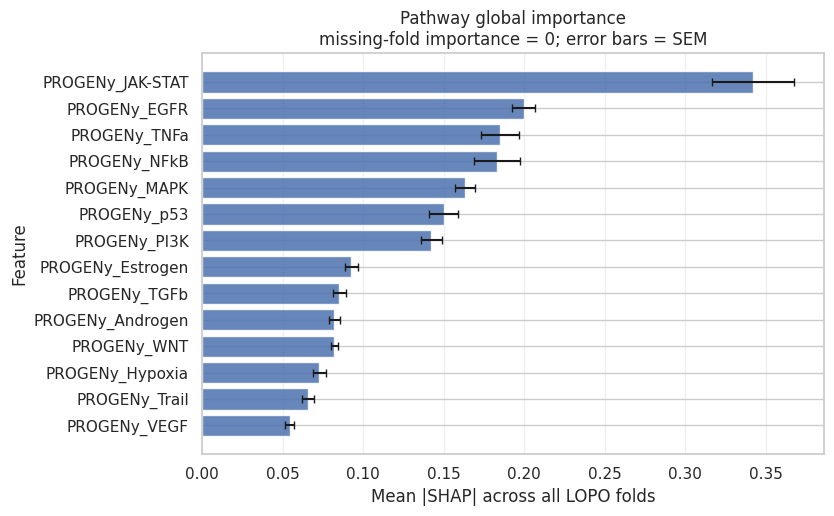

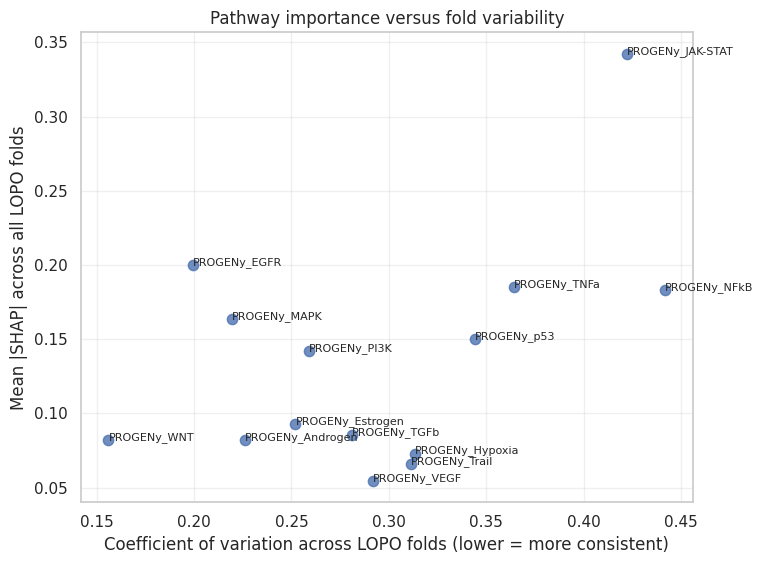

Pathway importance and consistency:


,feature,overall_mean_importance,overall_std_importance,conditional_mean_importance,n_folds_selected,selection_frequency,overall_sem_importance,cv_importance_all_folds,feature_type
0,PROGENy_JAK-STAT,0.342361,0.144497,0.342361,32,1.0,0.025544,0.422061,Pathway
1,PROGENy_EGFR,0.199701,0.039870,0.199701,32,1.0,0.007048,0.199646,Pathway
2,PROGENy_TNFa,0.184864,0.067296,0.184864,32,1.0,0.011896,0.364032,Pathway
3,PROGENy_NFkB,0.183364,0.081012,0.183364,32,1.0,0.014321,0.441813,Pathway
4,PROGENy_MAPK,0.163265,0.035811,0.163265,32,1.0,0.006330,0.219340,Pathway
5,PROGENy_p53,0.150028,0.051624,0.150028,32,1.0,0.009126,0.344099,Pathway
6,PROGENy_PI3K,0.142197,0.036850,0.142197,32,1.0,0.006514,0.259146,Pathway
7,PROGENy_Estrogen,0.092745,0.023379,0.092745,32,1.0,0.004133,0.252076,Pathway
8,PROGENy_TGFb,0.085263,0.023953,0.085263,32,1.0,0.004234,0.280927,Pathway
9,PROGENy_Androgen,0.082143,0.018583,0.082143,32,1.0,0.003285,0.226226,Pathway


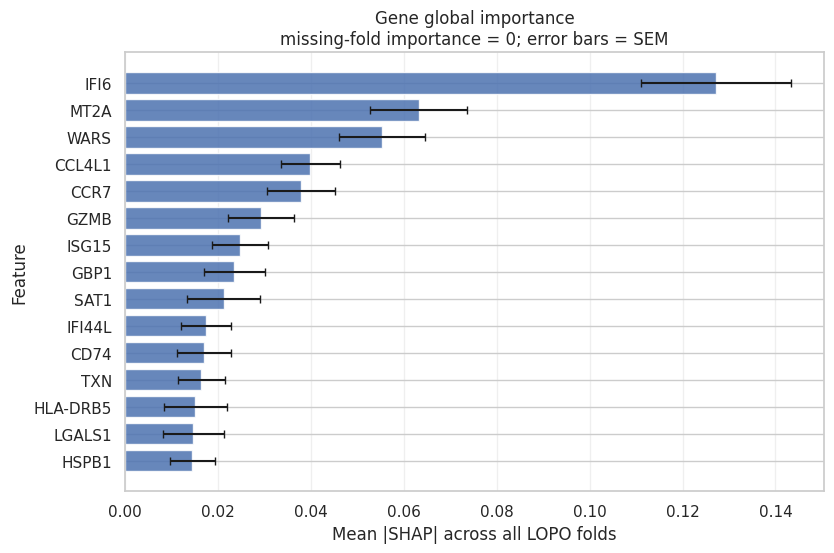

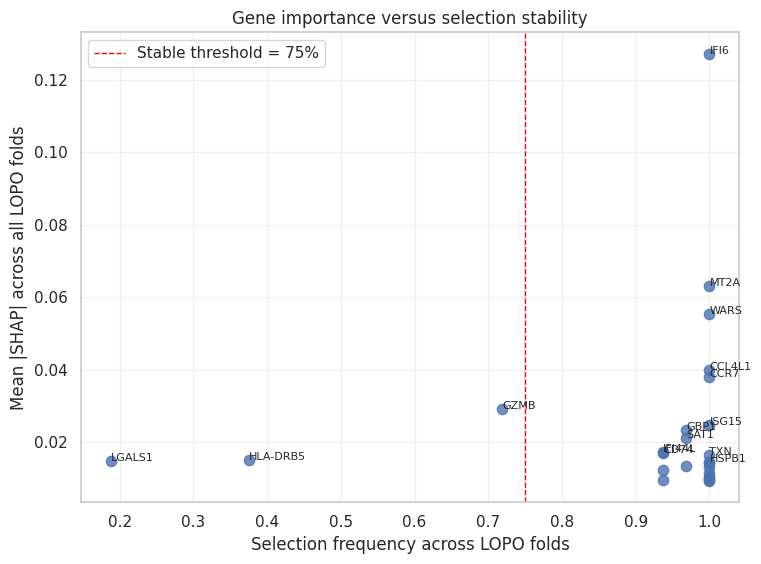

Gene importance and consistency:


,feature,overall_mean_importance,overall_std_importance,conditional_mean_importance,n_folds_selected,selection_frequency,overall_sem_importance,cv_importance_all_folds,feature_type
0,IFI6,0.127146,0.091350,0.127146,32,1.00000,0.016149,0.718468,Gene
1,MT2A,0.063175,0.059420,0.063175,32,1.00000,0.010504,0.940551,Gene
2,WARS,0.055281,0.052157,0.055281,32,1.00000,0.009220,0.943493,Gene
3,CCL4L1,0.039886,0.035813,0.039886,32,1.00000,0.006331,0.897880,Gene
4,CCR7,0.037894,0.041734,0.037894,32,1.00000,0.007378,1.101342,Gene
5,GZMB,0.029280,0.040203,0.040737,23,0.71875,0.007107,1.373075,Gene
6,ISG15,0.024814,0.034109,0.024814,32,1.00000,0.006030,1.374579,Gene
7,GBP1,0.023495,0.037317,0.024253,31,0.96875,0.006597,1.588299,Gene
8,SAT1,0.021217,0.044202,0.021901,31,0.96875,0.007814,2.083325,Gene
9,IFI44L,0.017367,0.030516,0.018524,30,0.93750,0.005395,1.757171,Gene


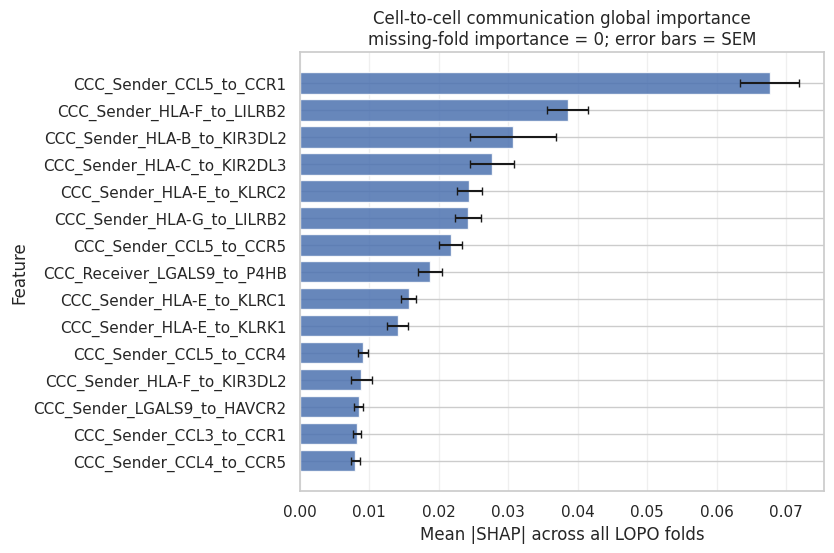

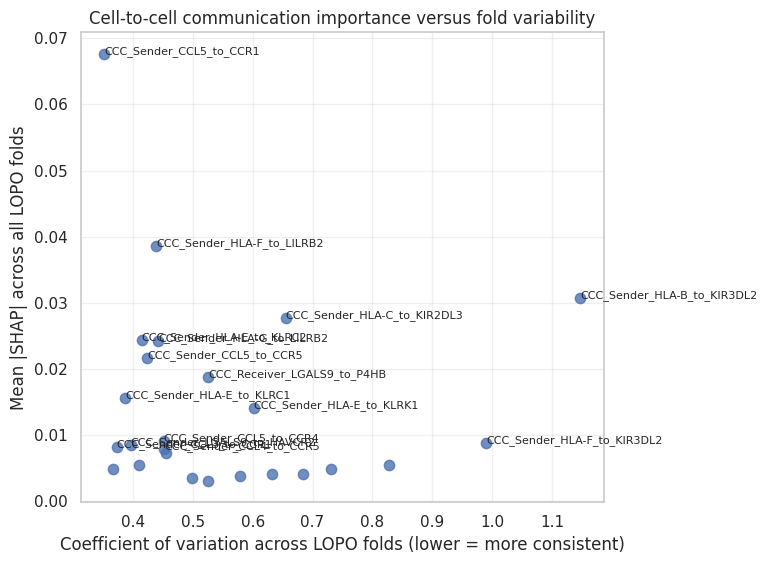

Cell-to-cell communication importance and consistency:


,feature,overall_mean_importance,overall_std_importance,conditional_mean_importance,n_folds_selected,selection_frequency,overall_sem_importance,cv_importance_all_folds,feature_type
0,CCC_Sender_CCL5_to_CCR1,0.067657,0.023857,0.067657,32,1.0,0.004217,0.352615,Cell-to-cell communication
1,CCC_Sender_HLA-F_to_LILRB2,0.038565,0.016923,0.038565,32,1.0,0.002992,0.438808,Cell-to-cell communication
2,CCC_Sender_HLA-B_to_KIR3DL2,0.030675,0.035189,0.030675,32,1.0,0.006221,1.147180,Cell-to-cell communication
3,CCC_Sender_HLA-C_to_KIR2DL3,0.027660,0.018115,0.027660,32,1.0,0.003202,0.654916,Cell-to-cell communication
4,CCC_Sender_HLA-E_to_KLRC2,0.024413,0.010122,0.024413,32,1.0,0.001789,0.414597,Cell-to-cell communication
5,CCC_Sender_HLA-G_to_LILRB2,0.024205,0.010695,0.024205,32,1.0,0.001891,0.441841,Cell-to-cell communication
6,CCC_Sender_CCL5_to_CCR5,0.021719,0.009217,0.021719,32,1.0,0.001629,0.424384,Cell-to-cell communication
7,CCC_Receiver_LGALS9_to_P4HB,0.018743,0.009859,0.018743,32,1.0,0.001743,0.525990,Cell-to-cell communication
8,CCC_Sender_HLA-E_to_KLRC1,0.015672,0.006072,0.015672,32,1.0,0.001073,0.387451,Cell-to-cell communication
9,CCC_Sender_HLA-E_to_KLRK1,0.014081,0.008472,0.014081,32,1.0,0.001498,0.601664,Cell-to-cell communication


In [8]:
def plot_global_importance_and_stability(explanation_result):
    """Plot corrected global importance and the appropriate fold-stability diagnostic."""
    tag = explanation_result['tag']
    summary = explanation_result['summary'].copy()
    top = summary.head(TOP_N_FEATURES).sort_values('overall_mean_importance')

    fig, ax = plt.subplots(figsize=(8.5, max(5, 0.38 * len(top))))
    ax.barh(
        top['feature'],
        top['overall_mean_importance'],
        xerr=top['overall_sem_importance'],
        capsize=3,
        alpha=0.85,
    )
    ax.set_xlabel('Mean |SHAP| across all LOPO folds')
    ax.set_ylabel('Feature')
    ax.set_title(
        f'{representation_label(tag)} global importance\n'
        'missing-fold importance = 0; error bars = SEM'
    )
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f'taskD_{tag}_global_importance_corrected.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()

    plot_df = summary.head(max(TOP_N_FEATURES, 25)).copy()
    fig, ax = plt.subplots(figsize=(7.8, 5.8))

    if tag == 'gene':
        ax.scatter(
            plot_df['selection_frequency'],
            plot_df['overall_mean_importance'],
            s=55,
            alpha=0.8,
        )
        for _, row in plot_df.head(TOP_N_FEATURES).iterrows():
            ax.text(
                row['selection_frequency'],
                row['overall_mean_importance'],
                row['feature'],
                fontsize=8,
            )
        ax.axvline(
            STABLE_GENE_FREQUENCY,
            color='red',
            linestyle='--',
            linewidth=1,
            label=f'Stable threshold = {STABLE_GENE_FREQUENCY:.0%}',
        )
        ax.set_xlabel('Selection frequency across LOPO folds')
        ax.set_title('Gene importance versus selection stability')
        ax.legend()
        stability_filename = 'taskD_gene_importance_vs_selection_frequency.png'
    else:
        plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
            subset=['cv_importance_all_folds']
        )
        ax.scatter(
            plot_df['cv_importance_all_folds'],
            plot_df['overall_mean_importance'],
            s=55,
            alpha=0.8,
        )
        for _, row in plot_df.head(TOP_N_FEATURES).iterrows():
            ax.text(
                row['cv_importance_all_folds'],
                row['overall_mean_importance'],
                row['feature'],
                fontsize=8,
            )
        ax.set_xlabel(
            'Coefficient of variation across LOPO folds '
            '(lower = more consistent)'
        )
        ax.set_title(
            f'{representation_label(tag)} importance versus fold variability'
        )
        stability_filename = f'taskD_{tag}_importance_vs_fold_variability.png'

    ax.set_ylabel('Mean |SHAP| across all LOPO folds')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / stability_filename,
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()



explainability_results = [
    pathway_explanations,
    gene_explanations,
    celltocell_explanations,
]

for explanation_result in explainability_results:
    plot_global_importance_and_stability(explanation_result)
    print(f'{representation_label(explanation_result["tag"])} importance and consistency:')
    display(explanation_result['summary'].head(TOP_N_FEATURES))



---
# 6. SHAP Directionality — Beeswarm-Like Plots

Mean absolute SHAP values show `how strongly` a feature matters, but not `in which direction`. The directionality plots show whether high or low feature values tend to push held-out predictions toward the Responder class.

- Positive SHAP values push the model toward **Responder**.
- Negative SHAP values push the model toward **Non-responder**.
- Point colour represents the fold-standardised feature value.

Gene, pathway, and cell-to-cell communication plots are generated separately so their scales and interpretations are not mixed. For communication features, the colour indicates the fold-standardised sender-like or receiver-like proxy value.

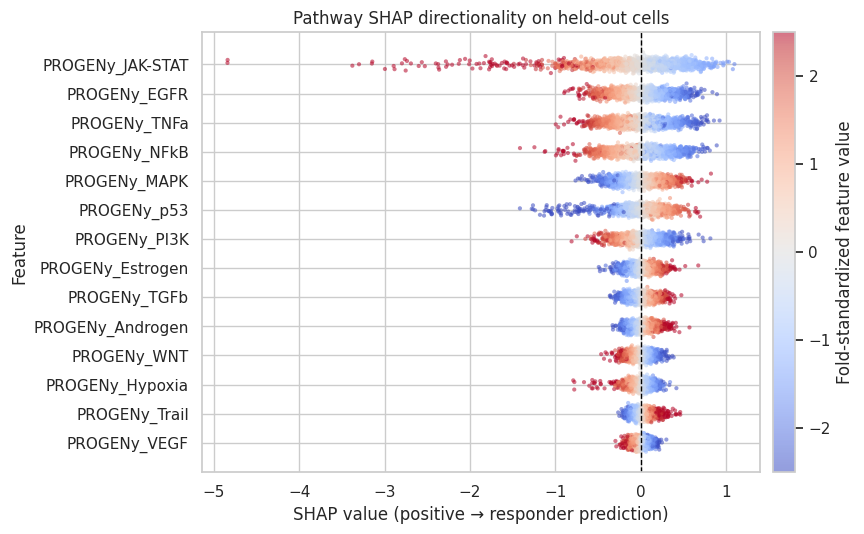

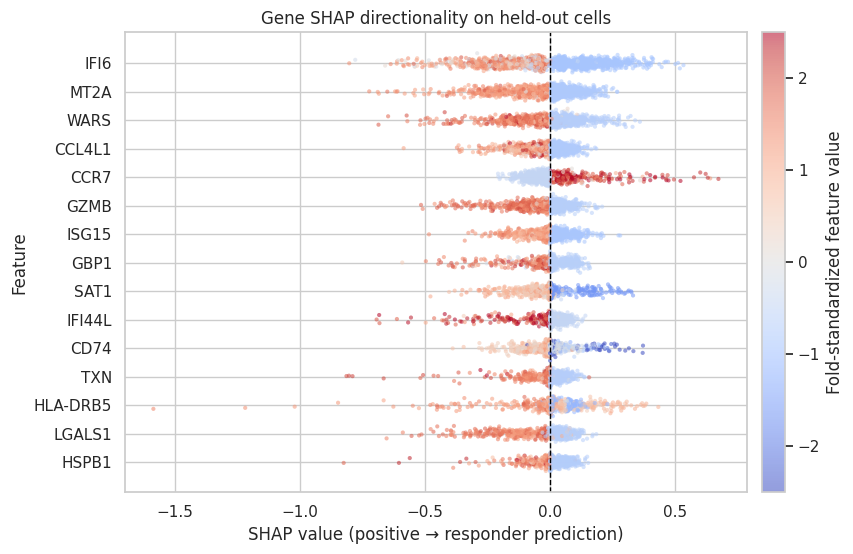

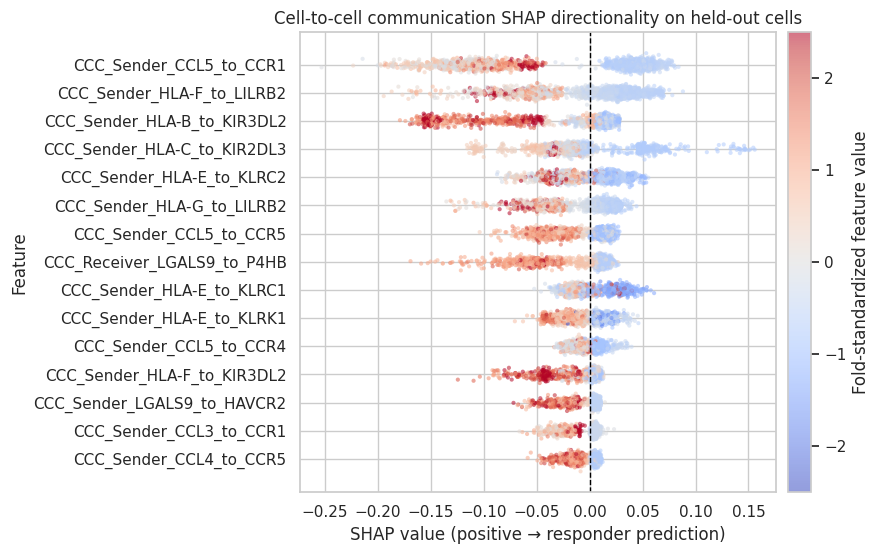

In [9]:
pathway_shap_points = plot_beeswarm_like(pathway_explanations)
gene_shap_points = plot_beeswarm_like(gene_explanations)
celltocell_shap_points = plot_beeswarm_like(celltocell_explanations)

---
# 7. SHAP Dependence Plots for the Top Features

A dependence plot asks:

> *When the value of this feature changes, how does its contribution to the prediction change?*

The x-axis shows the fold-standardised feature value and the y-axis shows the SHAP contribution of that feature. A quantile-binned mean line summarises the trend without imposing a linear relationship.

For genes, dependence plots prioritise features selected in at least 75% of LOPO folds. For cell-to-cell communication, sender-like and receiver-like features remain separate so their roles are not conflated. The reported Spearman correlation is descriptive only and must not be interpreted as a formal independent hypothesis test because cells from the same patient are not independent observations.

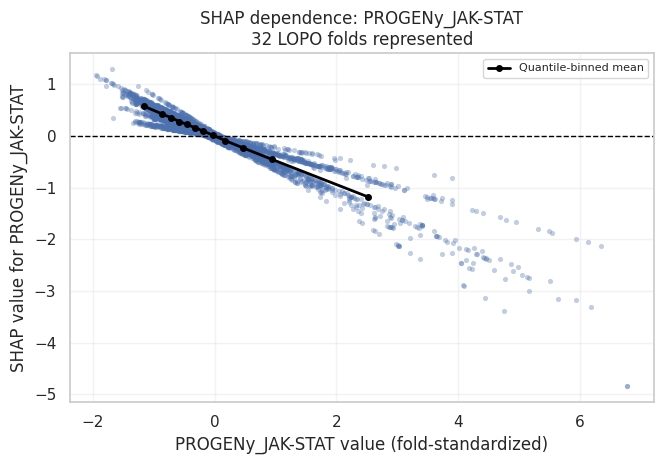

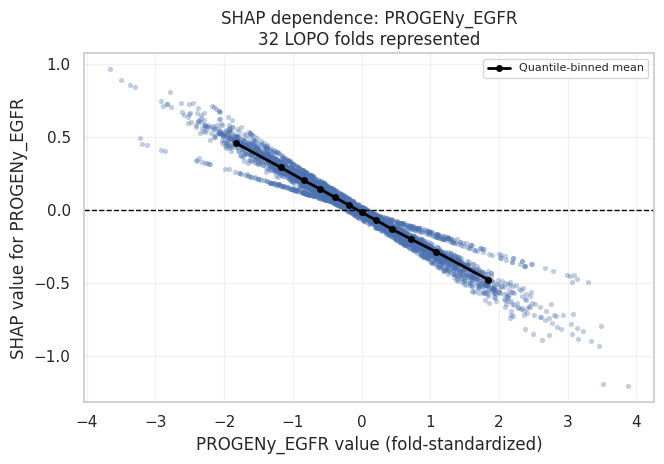

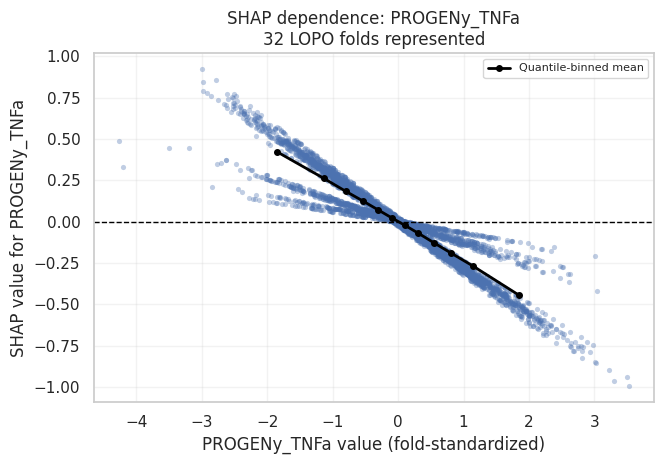

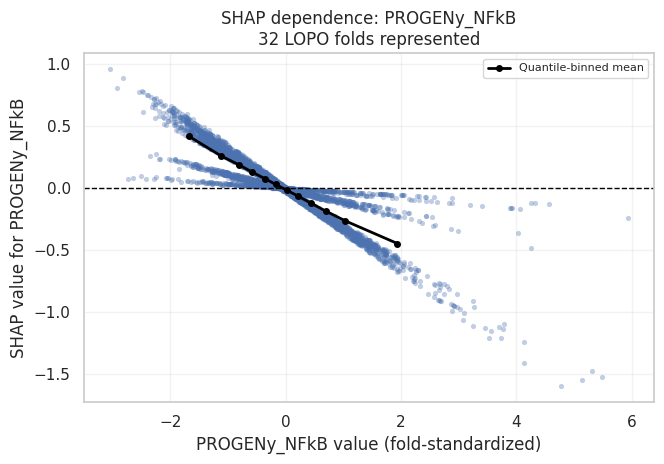

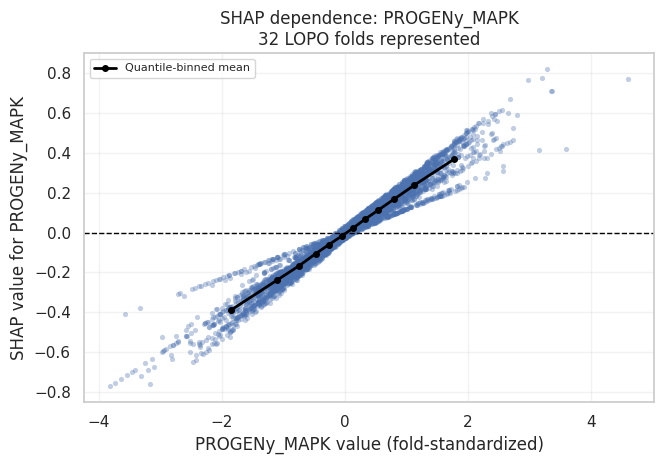

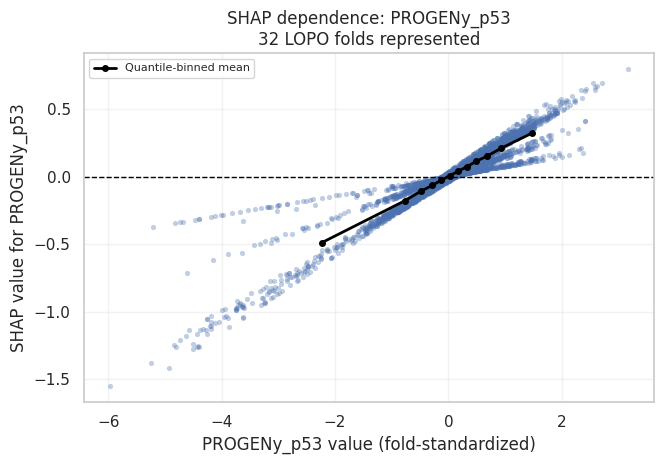

,feature,spearman_rho_feature_vs_shap,p_value_descriptive_only,direction,n_points,n_folds_with_shap
0,PROGENy_JAK-STAT,-0.963424,0.0,Higher value tends toward non-responder predic...,4800,32
1,PROGENy_EGFR,-0.990527,0.0,Higher value tends toward non-responder predic...,4800,32
2,PROGENy_TNFa,-0.970838,0.0,Higher value tends toward non-responder predic...,4800,32
3,PROGENy_NFkB,-0.951953,0.0,Higher value tends toward non-responder predic...,4800,32
4,PROGENy_MAPK,0.989031,0.0,Higher value tends toward responder prediction,4800,32
5,PROGENy_p53,0.974273,0.0,Higher value tends toward responder prediction,4800,32


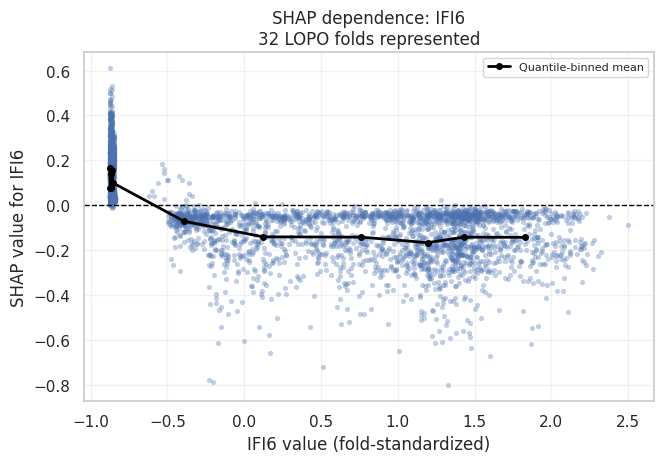

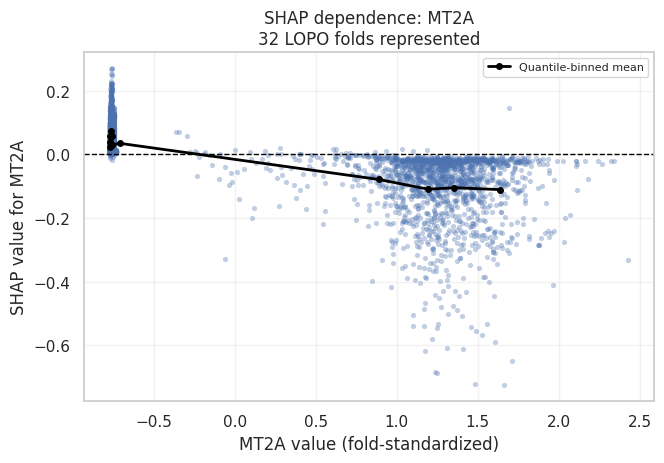

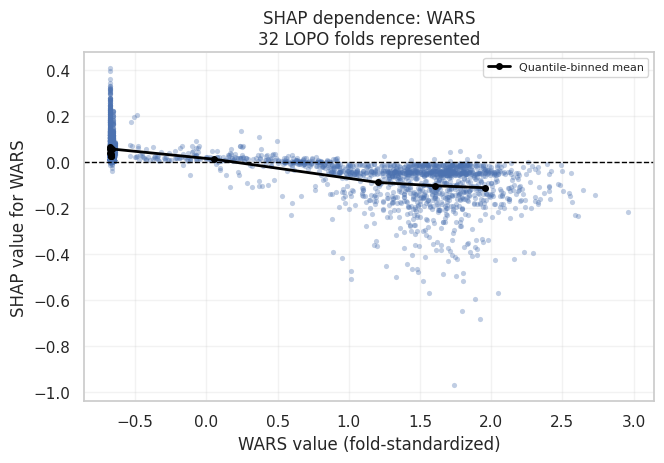

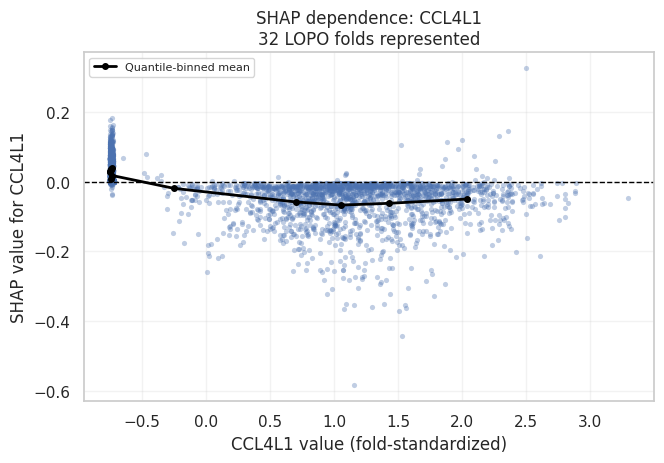

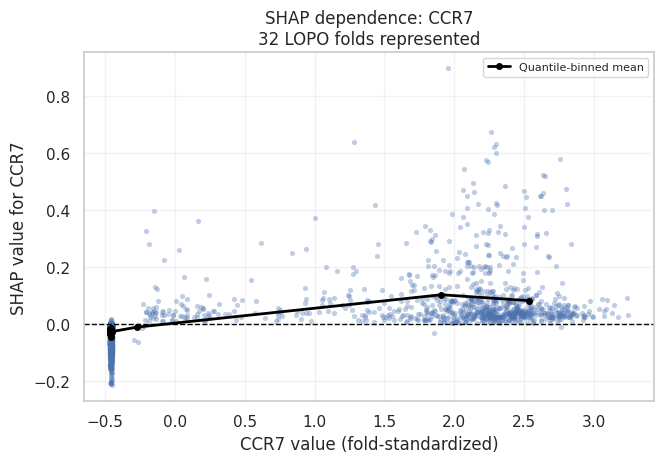

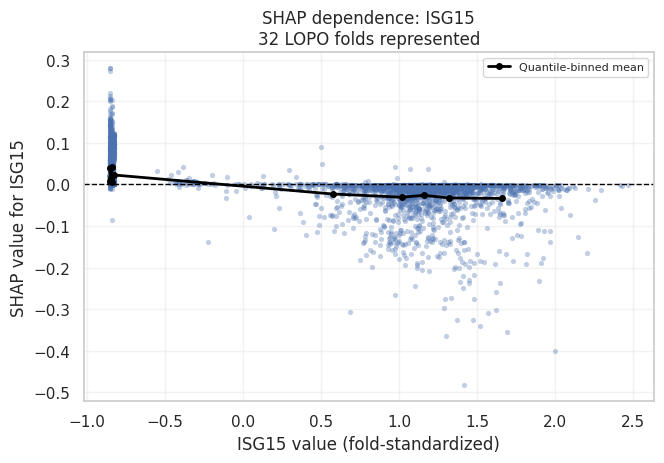

,feature,spearman_rho_feature_vs_shap,p_value_descriptive_only,direction,n_points,n_folds_with_shap
0,IFI6,-0.777925,0.000000e+00,Higher value tends toward non-responder predic...,4800,32
1,MT2A,-0.667776,0.000000e+00,Higher value tends toward non-responder predic...,4800,32
2,WARS,-0.623702,0.000000e+00,Higher value tends toward non-responder predic...,4800,32
3,CCL4L1,-0.692466,0.000000e+00,Higher value tends toward non-responder predic...,4800,32
4,CCR7,0.417924,2.766209e-202,Higher value tends toward responder prediction,4800,32
5,ISG15,-0.727651,0.000000e+00,Higher value tends toward non-responder predic...,4800,32


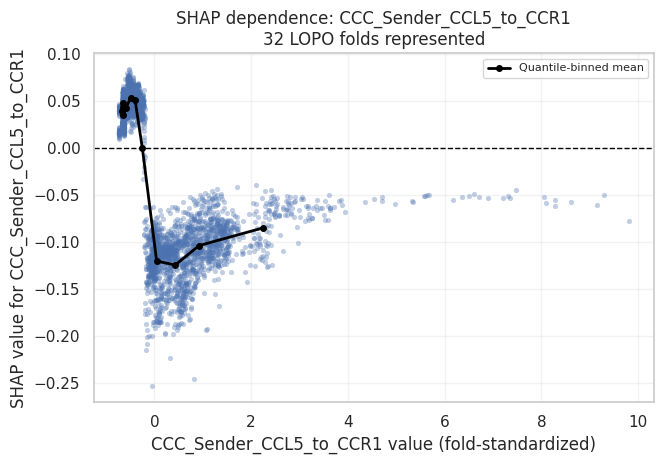

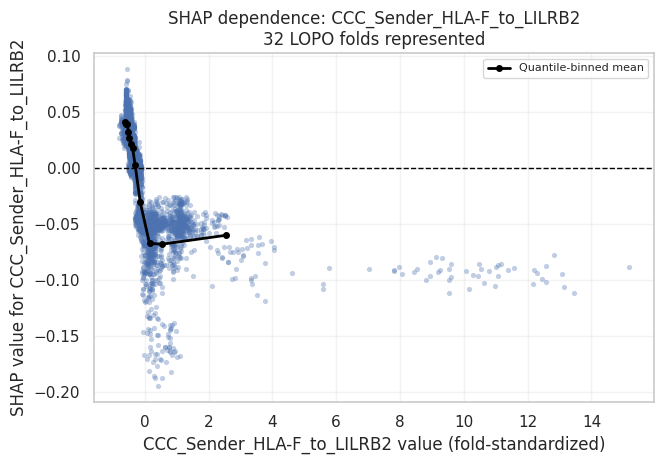

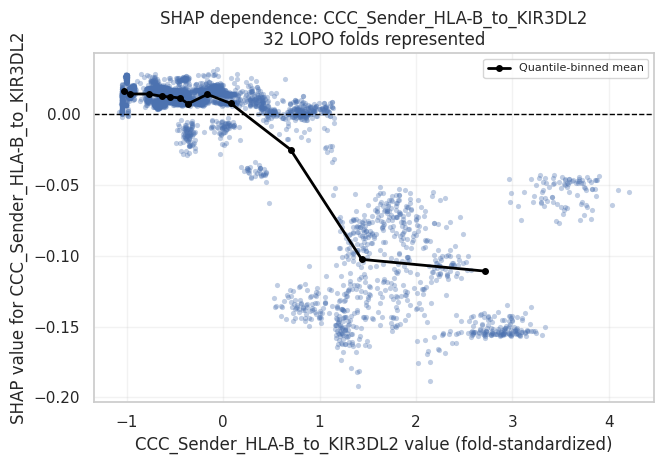

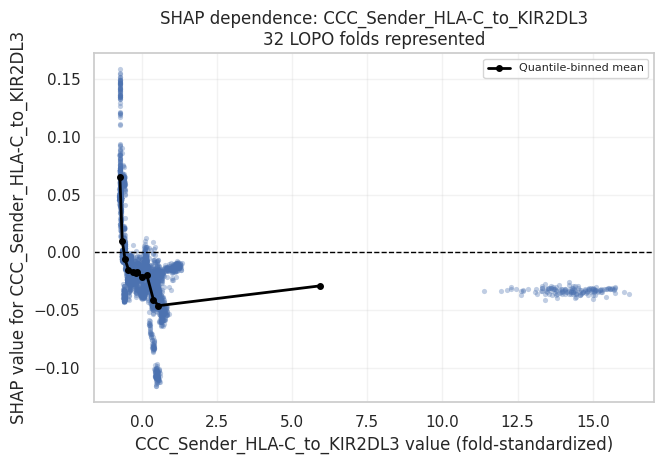

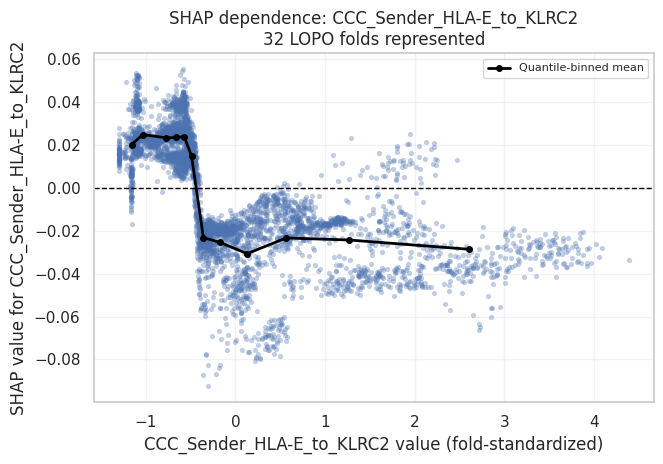

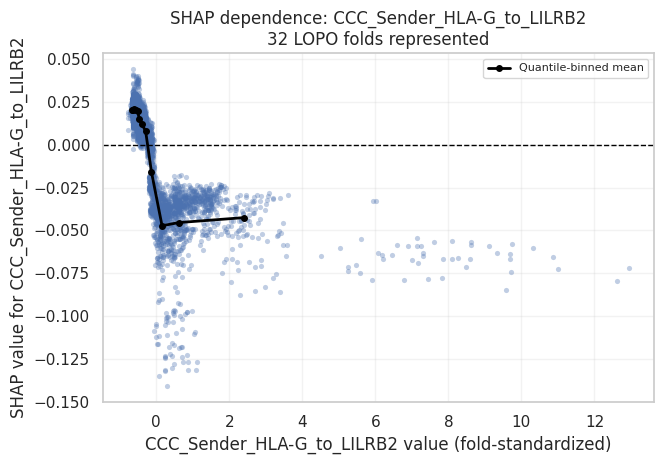

,feature,spearman_rho_feature_vs_shap,p_value_descriptive_only,direction,n_points,n_folds_with_shap
0,CCC_Sender_CCL5_to_CCR1,-0.600201,0.0,Higher value tends toward non-responder predic...,4800,32
1,CCC_Sender_HLA-F_to_LILRB2,-0.882890,0.0,Higher value tends toward non-responder predic...,4800,32
2,CCC_Sender_HLA-B_to_KIR3DL2,-0.624706,0.0,Higher value tends toward non-responder predic...,4800,32
3,CCC_Sender_HLA-C_to_KIR2DL3,-0.670262,0.0,Higher value tends toward non-responder predic...,4800,32
4,CCC_Sender_HLA-E_to_KLRC2,-0.766778,0.0,Higher value tends toward non-responder predic...,4800,32
5,CCC_Sender_HLA-G_to_LILRB2,-0.831093,0.0,Higher value tends toward non-responder predic...,4800,32


In [10]:
pathway_direction_summary = dependence_and_direction_summary(
    pathway_explanations, pathway_shap_points
)
gene_direction_summary = dependence_and_direction_summary(
    gene_explanations, gene_shap_points
)
celltocell_direction_summary = dependence_and_direction_summary(
    celltocell_explanations, celltocell_shap_points
)

---
# 8. SHAP Interaction Analysis

For tree-based models, SHAP interaction values estimate whether the contribution of one feature depends on another feature. This analysis is relevant to the PRECISE paper, which discusses context-dependent effects and feature pairs whose joint contribution may be informative.

The pathway model is Logistic Regression and therefore cannot represent non-linear feature interactions; no artificial pathway interaction heatmap is produced. For the XGBoost gene model and Random Forest cell-to-cell model, interaction strengths are:

- computed for stable genes and the highest-ranked communication features;
- calculated on held-out cells;
- aggregated across all eligible LOPO folds rather than a single convenient fold;
- accompanied by fold co-occurrence counts.

The heatmaps represent model interaction strength, not causal or experimentally validated molecular interactions. A cell-to-cell feature interaction also does not demonstrate communication between specific cell populations.

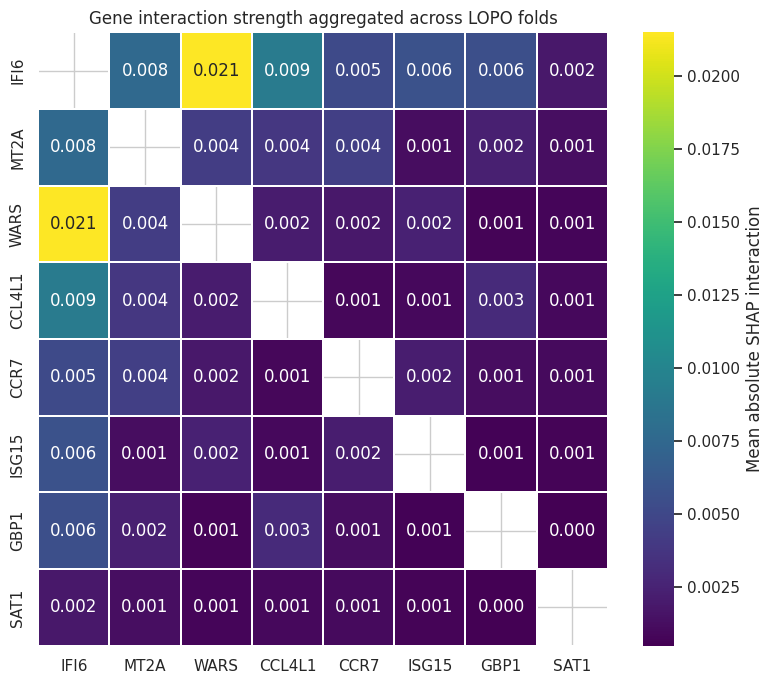

Fold co-occurrence counts for interaction pairs:


,IFI6,MT2A,WARS,CCL4L1,CCR7,ISG15,GBP1,SAT1
IFI6,0,32,32,32,32,32,31,31
MT2A,32,0,32,32,32,32,31,31
WARS,32,32,0,32,32,32,31,31
CCL4L1,32,32,32,0,32,32,31,31
CCR7,32,32,32,32,0,32,31,31
ISG15,32,32,32,32,32,0,31,31
GBP1,31,31,31,31,31,31,0,30
SAT1,31,31,31,31,31,31,30,0


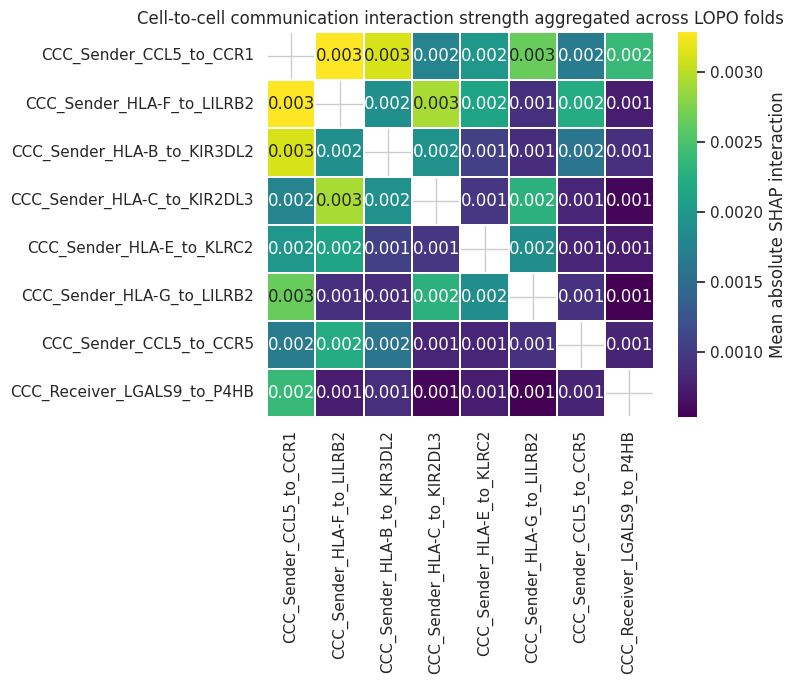

Fold co-occurrence counts for interaction pairs:


,CCC_Sender_CCL5_to_CCR1,CCC_Sender_HLA-F_to_LILRB2,CCC_Sender_HLA-B_to_KIR3DL2,CCC_Sender_HLA-C_to_KIR2DL3,CCC_Sender_HLA-E_to_KLRC2,CCC_Sender_HLA-G_to_LILRB2,CCC_Sender_CCL5_to_CCR5,CCC_Receiver_LGALS9_to_P4HB
CCC_Sender_CCL5_to_CCR1,0,32,32,32,32,32,32,32
CCC_Sender_HLA-F_to_LILRB2,32,0,32,32,32,32,32,32
CCC_Sender_HLA-B_to_KIR3DL2,32,32,0,32,32,32,32,32
CCC_Sender_HLA-C_to_KIR2DL3,32,32,32,0,32,32,32,32
CCC_Sender_HLA-E_to_KLRC2,32,32,32,32,0,32,32,32
CCC_Sender_HLA-G_to_LILRB2,32,32,32,32,32,0,32,32
CCC_Sender_CCL5_to_CCR5,32,32,32,32,32,32,0,32
CCC_Receiver_LGALS9_to_P4HB,32,32,32,32,32,32,32,0


In [11]:
def positive_class_interaction_values(raw_values):
    if isinstance(raw_values, list):
        return np.asarray(raw_values[-1])

    values = np.asarray(raw_values)

    if values.ndim == 4:
        if values.shape[-1] == 2:
            return values[:, :, :, 1]
        if values.shape[0] == 2:
            return values[1]

    return values


def aggregate_tree_interactions(bundle, explanation_result):
    """Aggregate absolute Tree-SHAP interactions over eligible LOPO folds."""
    tag = explanation_result['tag']
    summary = explanation_result['summary']
    candidates_table = (
        summary[summary['selection_frequency'] >= STABLE_GENE_FREQUENCY]
        if tag == 'gene' else summary
    )
    candidates = candidates_table.head(
        MAX_INTERACTION_FEATURES
    )['feature'].tolist()

    if len(candidates) < 2:
        print(
            f'Not enough {representation_label(tag).lower()} features '
            'for cross-fold interaction analysis.'
        )
        return None, None

    strength_sum = pd.DataFrame(
        0.0,
        index=candidates,
        columns=candidates
    )
    fold_counts = pd.DataFrame(
        0,
        index=candidates,
        columns=candidates,
        dtype=int
    )

    for fold_key, artifact in bundle['fold_artifacts'].items():
        model = artifact['model']

        if not hasattr(model, 'feature_importances_'):
            continue

        feature_names = list(artifact['feature_names'])
        present = [
            feature
            for feature in candidates
            if feature in feature_names
        ]

        if len(present) < 2:
            continue

        X_test = np.asarray(artifact['Xte_transformed'])
        rng = np.random.default_rng(SEED + int(fold_key))

        selected_rows = rng.choice(
            X_test.shape[0],
            size=min(
                MAX_INTERACTION_CELLS_PER_FOLD,
                X_test.shape[0]
            ),
            replace=False
        )

        try:
            explainer = shap.TreeExplainer(model)

            raw = explainer.shap_interaction_values(
                X_test[selected_rows]
            )

            interactions = positive_class_interaction_values(raw)

            if interactions.ndim != 3:
                print(
                    f'Fold {fold_key}: unexpected interaction '
                    'dimensions; skipped.'
                )
                continue

            positions = [
                feature_names.index(feature)
                for feature in present
            ]

            local = np.abs(
                interactions[:, positions, :][:, :, positions]
            ).mean(axis=0)

            for i, feature_i in enumerate(present):
                for j, feature_j in enumerate(present):
                    if feature_i == feature_j:
                        continue

                    strength_sum.loc[
                        feature_i, feature_j
                    ] += float(local[i, j])

                    fold_counts.loc[
                        feature_i, feature_j
                    ] += 1

        except Exception as error:
            print(
                f'Fold {fold_key}: interaction calculation skipped. '
                f'{type(error).__name__}: {error}'
            )

    mean_strength = strength_sum.div(
        fold_counts.replace(0, np.nan)
    )

    # Set the diagonal safely without modifying a read-only NumPy view.
    for feature in candidates:
        mean_strength.loc[feature, feature] = np.nan
        fold_counts.loc[feature, feature] = 0

    mean_strength.to_csv(
        OUTPUT_DIR
        / f'taskD_{tag}_interaction_strength_across_folds.csv'
    )

    fold_counts.to_csv(
        OUTPUT_DIR
        / f'taskD_{tag}_interaction_fold_counts.csv'
    )

    if mean_strength.notna().sum().sum() == 0:
        print(f'No {representation_label(tag).lower()} interactions could be aggregated.')
        return mean_strength, fold_counts

    fig, ax = plt.subplots(figsize=(8, 7))

    sns.heatmap(
        mean_strength,
        cmap='viridis',
        annot=True,
        fmt='.3f',
        linewidths=0.3,
        cbar_kws={
            'label': 'Mean absolute SHAP interaction'
        },
        ax=ax
    )

    ax.set_title(
        f'{representation_label(tag)} interaction strength '
        'aggregated across LOPO folds'
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR
        / f'taskD_{tag}_interactions_across_folds.png',
        dpi=180,
        bbox_inches='tight'
    )

    plt.show()

    print('Fold co-occurrence counts for interaction pairs:')
    display(fold_counts)

    return mean_strength, fold_counts


gene_interaction_strength, gene_interaction_counts = (
    aggregate_tree_interactions(
        gene_bundle,
        gene_explanations
    )
)

celltocell_interaction_strength, celltocell_interaction_counts = (
    aggregate_tree_interactions(
        celltocell_bundle,
        celltocell_explanations
    )
)

---
# 9. Sample-Level Error Analysis: ROC, Precision–Recall and Calibration

The primary endpoint is `biological-sample-level prediction`, so discrimination and calibration are evaluated using the held-out sample scores from Task C.

1. **ROC curve** — summarises discrimination across thresholds.
2. **Precision–Recall curve** — focuses on identification of responders and is useful with class imbalance.
3. **Calibration curve** — compares predicted probabilities with observed response frequency.

Calibration is descriptive here because the models were optimised for discrimination and the sample probabilities were formed by averaging weighted cell-level predictions. Good ROC-AUC does not automatically imply well-calibrated probabilities.

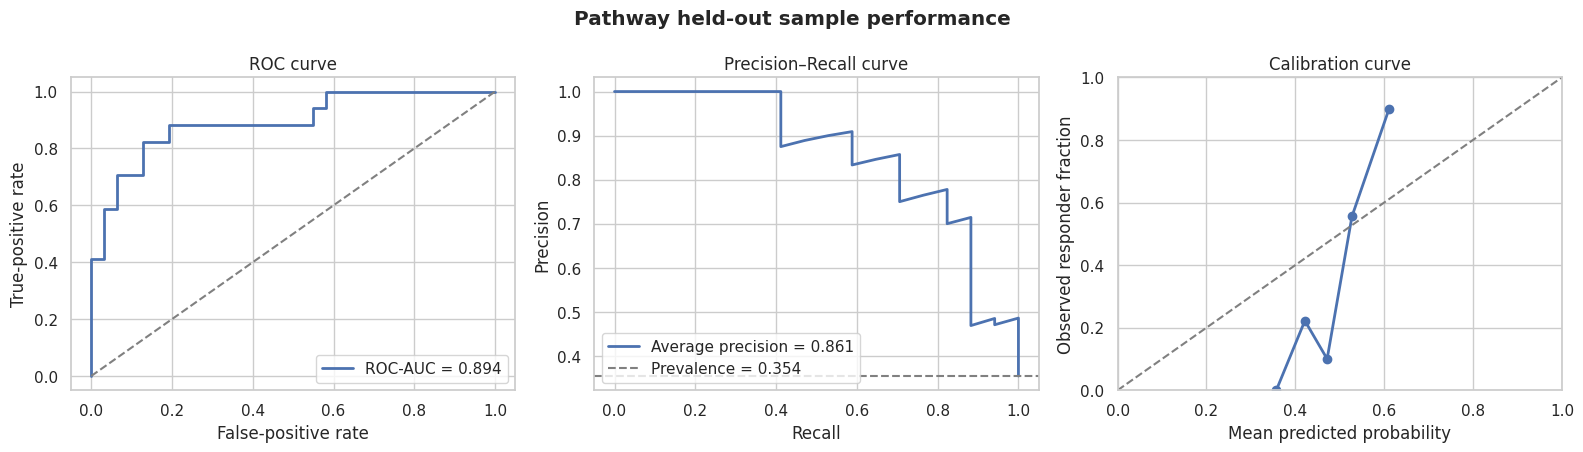

Pathway sample-level ROC-AUC: 0.8937
Pathway sample-level average precision: 0.8605


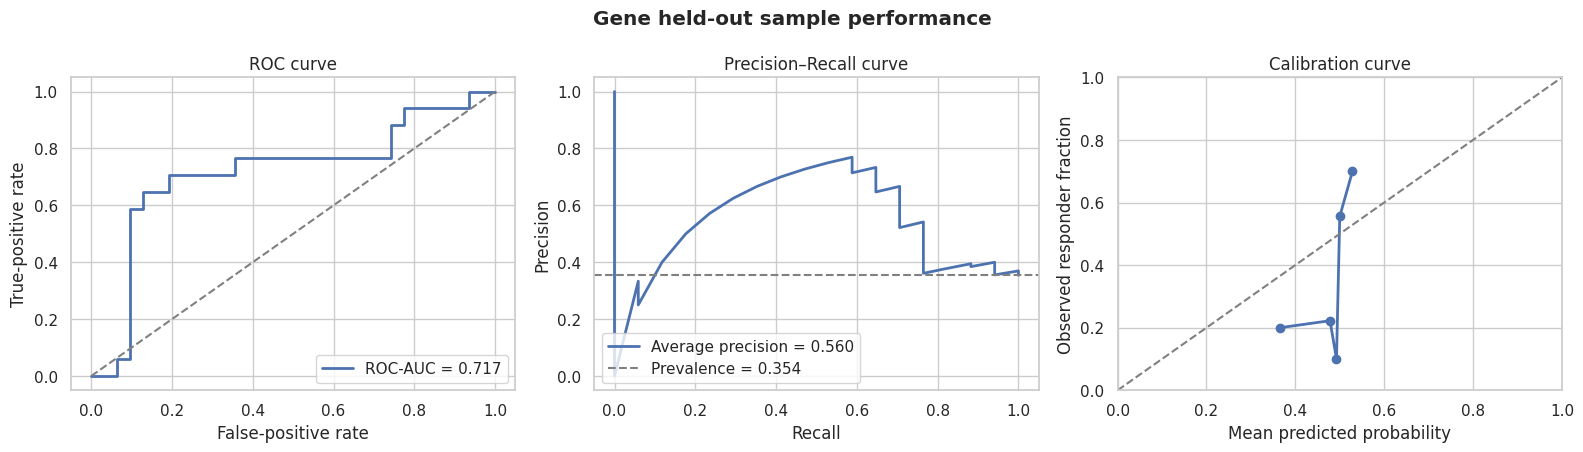

Gene sample-level ROC-AUC: 0.7173
Gene sample-level average precision: 0.5604


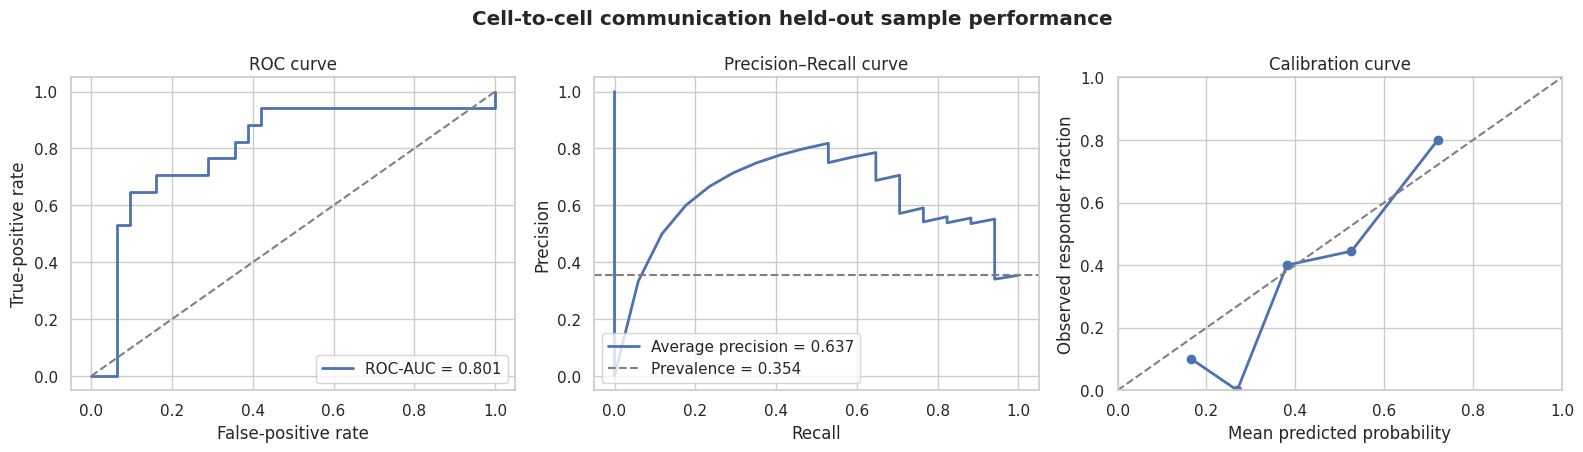

Cell-to-cell communication sample-level ROC-AUC: 0.8008
Cell-to-cell communication sample-level average precision: 0.6373


In [12]:
def plot_discrimination_and_calibration(prediction_result):
    tag = prediction_result['tag']
    data = prediction_result['sample_results']
    y_true = data['true_label'].to_numpy(dtype=int)
    y_score = data['sample_score'].to_numpy(dtype=float)

    auc_value = roc_auc_score(y_true, y_score)
    ap_value = average_precision_score(y_true, y_score)
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    axes[0].plot(false_positive_rate, true_positive_rate, linewidth=2,
                 label=f'ROC-AUC = {auc_value:.3f}')
    axes[0].plot([0, 1], [0, 1], '--', color='grey')
    axes[0].set(xlabel='False-positive rate', ylabel='True-positive rate',
                title='ROC curve')
    axes[0].legend(loc='lower right')

    axes[1].plot(recall, precision, linewidth=2,
                 label=f'Average precision = {ap_value:.3f}')
    axes[1].axhline(y_true.mean(), linestyle='--', color='grey',
                    label=f'Prevalence = {y_true.mean():.3f}')
    axes[1].set(xlabel='Recall', ylabel='Precision',
                title='Precision–Recall curve')
    axes[1].legend(loc='lower left')

    n_bins = min(5, max(2, len(np.unique(y_score))))
    observed, predicted = calibration_curve(
        y_true, y_score, n_bins=n_bins, strategy='quantile'
    )
    axes[2].plot(predicted, observed, marker='o', linewidth=2)
    axes[2].plot([0, 1], [0, 1], '--', color='grey')
    axes[2].set(xlabel='Mean predicted probability',
                ylabel='Observed responder fraction', title='Calibration curve')
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)

    fig.suptitle(f'{representation_label(tag)} held-out sample performance', fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f'taskD_{tag}_roc_pr_calibration.png',
        dpi=180, bbox_inches='tight'
    )
    plt.show()
    print(f'{representation_label(tag)} sample-level ROC-AUC: {auc_value:.4f}')
    print(f'{representation_label(tag)} sample-level average precision: {ap_value:.4f}')
    return {'auc': auc_value, 'average_precision': ap_value}


pathway_performance = plot_discrimination_and_calibration(pathway_predictions)
gene_performance = plot_discrimination_and_calibration(gene_predictions)
celltocell_performance = plot_discrimination_and_calibration(
    celltocell_predictions
)

---
# 10. Confusion Matrices and Ordered Prediction Scores

Confusion matrices classify samples using a fixed threshold of 0.5. This threshold is retained for a transparent descriptive comparison, but it is **not claimed to be clinically optimised** and may not be optimal for weighted or uncalibrated model probabilities.

The ordered score plots show whether errors are close to the decision boundary or confidently incorrect. Gene, pathway, and cell-to-cell communication results are displayed separately.

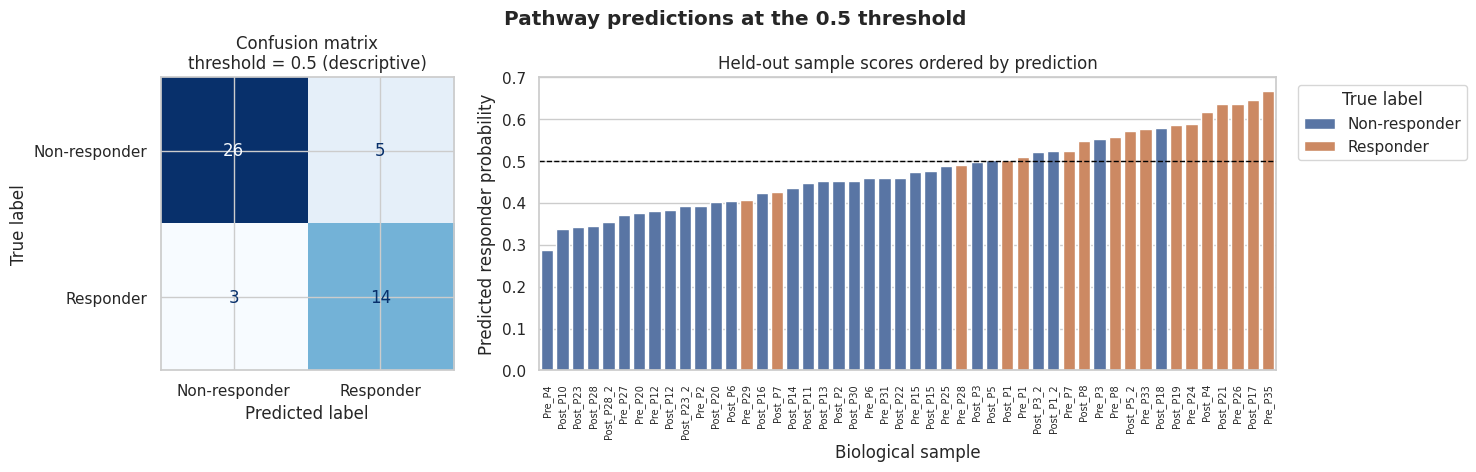

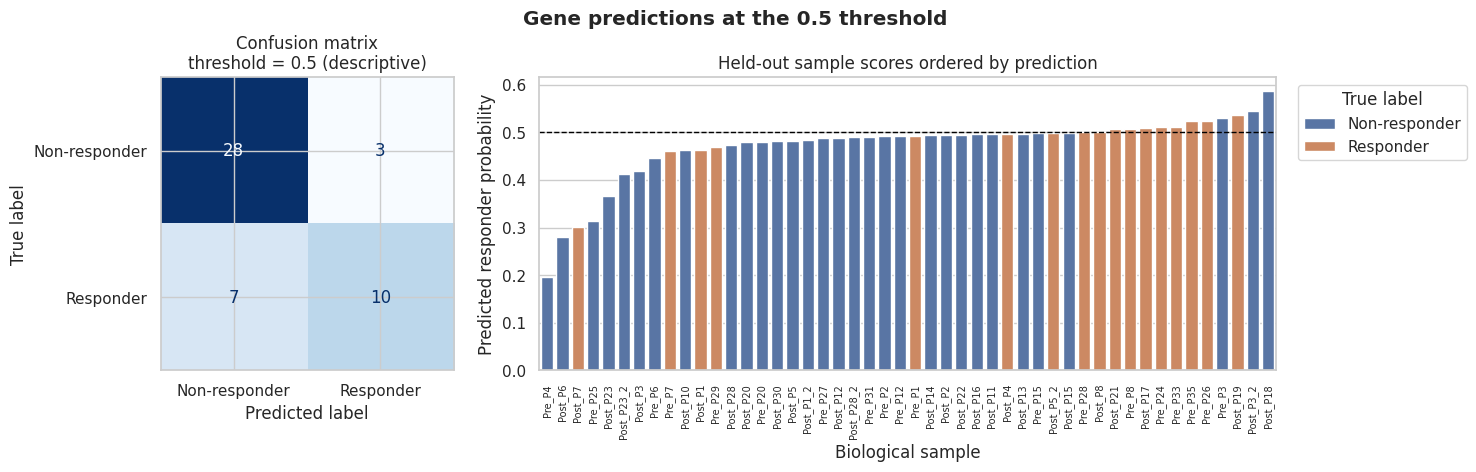

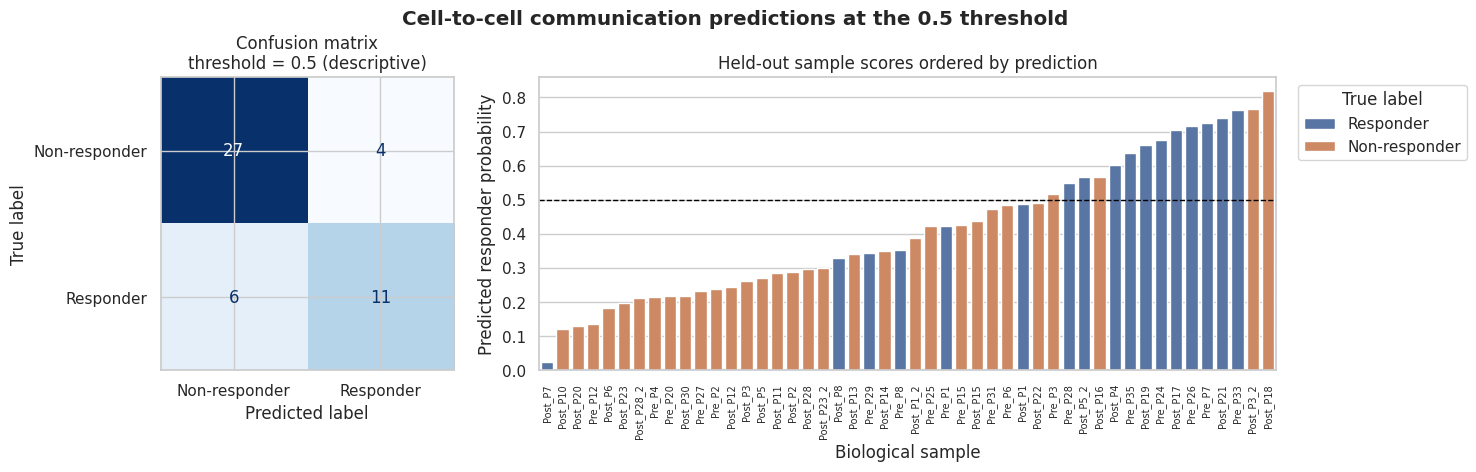

In [13]:
def plot_confusion_and_scores(prediction_result):
    tag = prediction_result['tag']
    data = prediction_result['sample_results'].copy()
    matrix = confusion_matrix(data['true_label'], data['y_pred'], labels=[0, 1])

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={'width_ratios': [1, 2.4]})
    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=['Non-responder', 'Responder']
    )
    display_object.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
    axes[0].set_title('Confusion matrix\nthreshold = 0.5 (descriptive)')

    ordered = data.sort_values('sample_score').copy()
    ordered['response_label'] = ordered['true_label'].map(
        {0: 'Non-responder', 1: 'Responder'}
    )
    sns.barplot(
        data=ordered, x='sample_id', y='sample_score', hue='response_label',
        dodge=False, ax=axes[1]
    )
    axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Biological sample')
    axes[1].set_ylabel('Predicted responder probability')
    axes[1].set_title('Held-out sample scores ordered by prediction')
    axes[1].tick_params(axis='x', labelrotation=90, labelsize=7)
    axes[1].legend(title='True label', bbox_to_anchor=(1.02, 1), loc='upper left')

    fig.suptitle(f'{representation_label(tag)} predictions at the 0.5 threshold', fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f'taskD_{tag}_confusion_and_ordered_scores.png',
        dpi=180, bbox_inches='tight'
    )
    plt.show()
    return matrix


pathway_confusion = plot_confusion_and_scores(pathway_predictions)
gene_confusion = plot_confusion_and_scores(gene_predictions)
celltocell_confusion = plot_confusion_and_scores(celltocell_predictions)

---
# 11. False Positives, False Negatives and Uncertain Samples

This section lists the actual held-out errors:

- **False positives:** non-responders predicted as responders.
- **False negatives:** responders predicted as non-responders.
- **Most uncertain samples:** scores closest to 0.5, regardless of correctness.

These tables support error analysis but do not by themselves establish why a patient was misclassified. Clinical subgroup, timepoint, sample size, and immune-cell composition should be examined before proposing a biological explanation.

In [14]:
def inspect_errors(prediction_result):
    tag = prediction_result['tag']
    data = prediction_result['sample_results']
    errors = data[~data['correct']].sort_values('confidence_margin', ascending=False).copy()
    false_positives = errors[errors['error_type'] == 'False positive'].copy()
    false_negatives = errors[errors['error_type'] == 'False negative'].copy()
    uncertain = data.sort_values('confidence_margin').copy()

    preferred_columns = [
        'patient_id', 'sample_id', 'true_label', 'sample_score', 'y_pred',
        'error_type', 'n_cells', 'confidence_margin'
    ]
    columns = [column for column in preferred_columns if column in data.columns]

    print(f'\n{representation_label(tag)}: {len(errors)} misclassified samples / {len(data)}')
    print(f'False positives: {len(false_positives)}')
    display(false_positives[columns])
    print(f'False negatives: {len(false_negatives)}')
    display(false_negatives[columns])
    print('Most uncertain samples:')
    display(uncertain[columns].head(10))

    errors.to_csv(OUTPUT_DIR / f'taskD_{tag}_misclassified_samples.csv', index=False)
    false_positives.to_csv(OUTPUT_DIR / f'taskD_{tag}_false_positives.csv', index=False)
    false_negatives.to_csv(OUTPUT_DIR / f'taskD_{tag}_false_negatives.csv', index=False)
    uncertain.to_csv(OUTPUT_DIR / f'taskD_{tag}_uncertain_samples.csv', index=False)
    return errors


pathway_errors = inspect_errors(pathway_predictions)
gene_errors = inspect_errors(gene_predictions)
celltocell_errors = inspect_errors(celltocell_predictions)


Pathway: 8 misclassified samples / 48
False positives: 5


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
13,P18,Post_P18,0,0.580193,1,False positive,357,0.080193
33,P3,Pre_P3,0,0.553145,1,False positive,245,0.053145
1,P1,Post_P1_2,0,0.524036,1,False positive,353,0.024036
32,P3,Post_P3_2,0,0.522765,1,False positive,358,0.022765
40,P5,Post_P5,0,0.502498,1,False positive,292,0.002498


False negatives: 3


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
30,P29,Pre_P29,1,0.406119,0,False negative,163,0.093881
44,P7,Post_P7,1,0.425829,0,False negative,231,0.074171
29,P28,Pre_P28,1,0.490544,0,False negative,337,0.009456


Most uncertain samples:


...

,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
13,P18,Post_P18,0,0.818209,1,False positive,357,0.318209
32,P3,Post_P3_2,0,0.765889,1,False positive,358,0.265889
11,P16,Post_P16,0,0.567072,1,False positive,463,0.067072
33,P3,Pre_P3,0,0.516053,1,False positive,245,0.016053


False negatives: 6


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
44,P7,Post_P7,1,0.025711,0,False negative,231,0.474289
46,P8,Post_P8,1,0.328950,0,False negative,409,0.171050
30,P29,Pre_P29,1,0.343016,0,False negative,163,0.156984
47,P8,Pre_P8,1,0.351646,0,False negative,267,0.148354
2,P1,Pre_P1,1,0.424340,0,False negative,229,0.075660
0,P1,Post_P1,1,0.487105,0,False negative,291,0.012895


Most uncertain samples:


,patient_id,sample_id,true_label,sample_score,y_pred,error_type,n_cells,confidence_margin
20,P22,Post_P22,0,0.489698,0,Correct,260,0.010302
0,P1,Post_P1,1,0.487105,0,False negative,291,0.012895
43,P6,Pre_P6,0,0.484661,0,Correct,288,0.015339
33,P3,Pre_P3,0,0.516053,1,False positive,245,0.016053
35,P31,Pre_P31,0,0.474075,0,Correct,351,0.025925
29,P28,Pre_P28,1,0.549880,1,Correct,337,0.049880
9,P15,Post_P15,0,0.437406,0,Correct,304,0.062594
41,P5,Post_P5_2,1,0.565862,1,Correct,336,0.065862
11,P16,Post_P16,0,0.567072,1,False positive,463,0.067072
10,P15,Pre_P15,0,0.425756,0,Correct,304,0.074244


---
# 12. Patient-Level and Cell-Level Probability Distributions

The classifier operates at cell level, while predictions are aggregated to biological samples. The boxplots below test whether a sample score is supported by a consistent cell-level signal or is produced by a heterogeneous distribution containing distinct cell subpopulations.

A wide distribution does not necessarily indicate model failure. It may reflect genuine immune-cell heterogeneity, but it also means the aggregated prediction is more sensitive to which cells are retained.

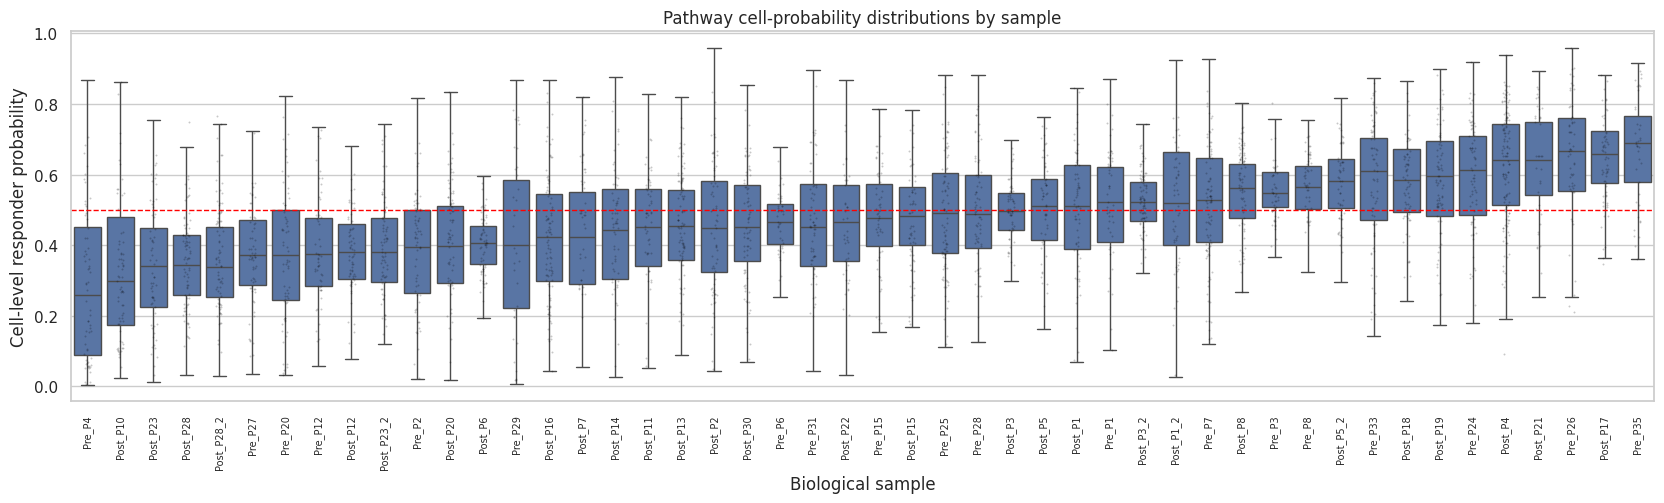

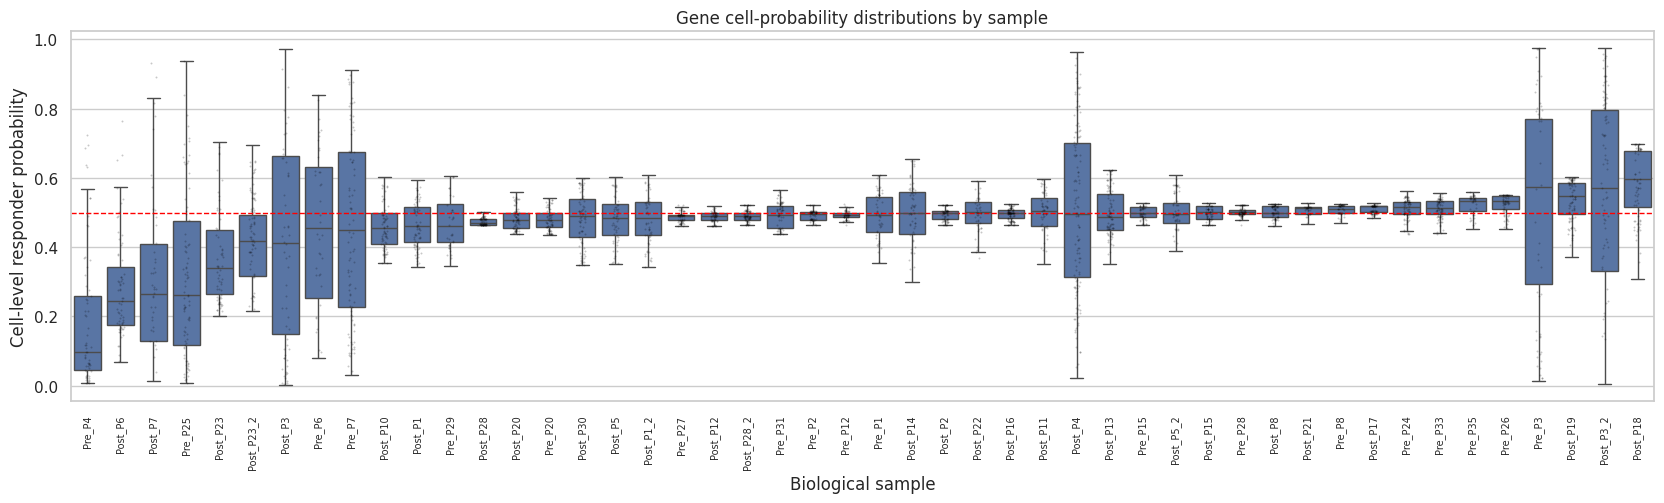

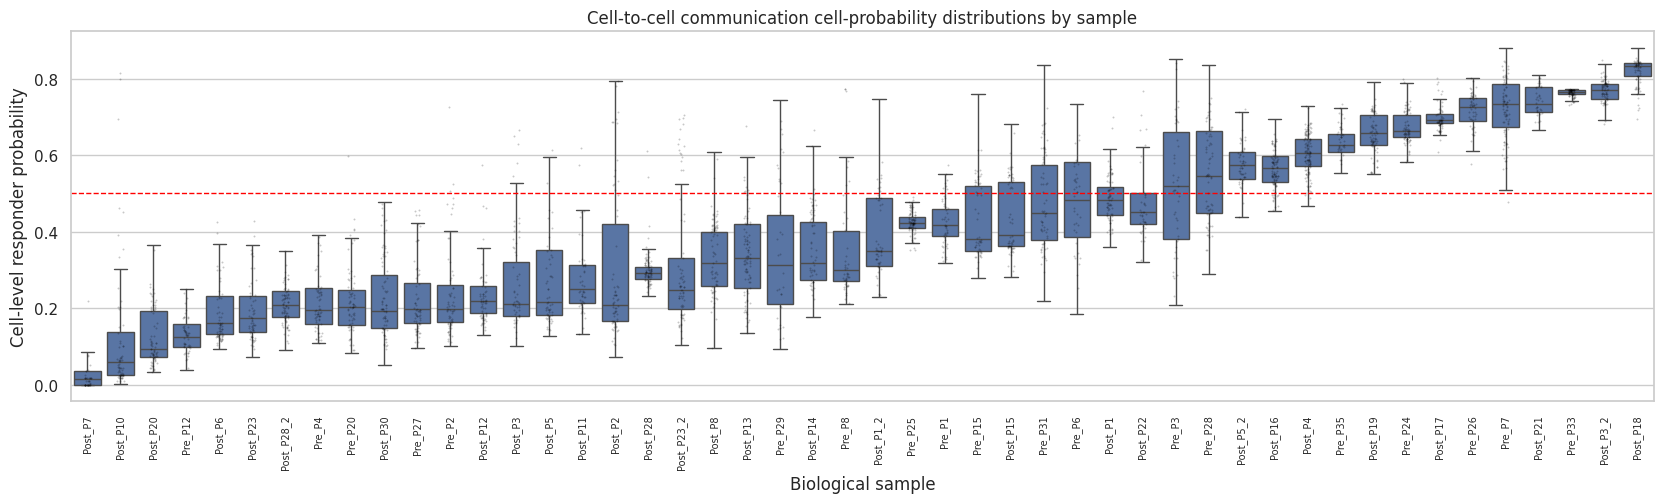

In [15]:
def plot_cell_probability_distributions(prediction_result):
    tag = prediction_result['tag']
    cells = prediction_result['cell_predictions']
    samples = prediction_result['sample_results']
    order = samples.sort_values('sample_score')['sample_id'].astype(str).tolist()

    fig, ax = plt.subplots(figsize=(max(11, 0.35 * len(order)), 5.2))
    sns.boxplot(
        data=cells, x='sample_id', y='cell_probability', order=order,
        showfliers=False, ax=ax
    )
    points = cells.sample(min(len(cells), 3000), random_state=SEED)
    sns.stripplot(
        data=points, x='sample_id', y='cell_probability', order=order,
        size=1.4, alpha=0.22, color='black', ax=ax
    )
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Biological sample')
    ax.set_ylabel('Cell-level responder probability')
    ax.set_title(f'{representation_label(tag)} cell-probability distributions by sample')
    ax.tick_params(axis='x', labelrotation=90, labelsize=7)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f'taskD_{tag}_cell_probability_distributions.png',
        dpi=180, bbox_inches='tight'
    )
    plt.show()


plot_cell_probability_distributions(pathway_predictions)
plot_cell_probability_distributions(gene_predictions)
plot_cell_probability_distributions(celltocell_predictions)

---
# 13. Cell-Filtering Sensitivity Analysis

The PRECISE paper proposes cell filtration to reduce the contribution of non-informative cells. We examine whether performance changes when different fractions of uncertain cells are excluded, because the article does not report a systematic comparison of all alternative thresholds.

Cell informativeness is approximated using the absolute distance between the predicted cell probability and the classification threshold:

```math
\text{Cell informativeness} = |p_{\text{cell}}-0.5|
```

Cells with probabilities close to 0.5 are considered less informative, whereas cells with probabilities closer to 0 or 1 are considered more confident. Within each biological sample, increasing fractions of the least informative cells are removed, and the sample score is recalculated as the mean probability of the remaining cells. The fractions examined are 0%, 20%, 30%, 40%, 50%, and 60%.

Uncertainty is estimated with a **patient-cluster bootstrap**, which resamples whole patients rather than treating repeated samples from the same patient as independent.

,fraction_cells_removed,sample_auc,patient_bootstrap_mean_auc,ci_lower,ci_upper,mean_cells_kept
0,0.0,0.8937,0.8945,0.7740,0.9822,339.3958
1,0.2,0.8899,0.8910,0.7662,0.9822,271.9792
2,0.3,0.8861,0.8874,0.7614,0.9822,238.0833
3,0.4,0.8843,0.8855,0.7609,0.9822,204.0208
4,0.5,0.8843,0.8856,0.7534,0.9822,170.0000
5,0.6,0.8805,0.8821,0.7473,0.9822,136.2500


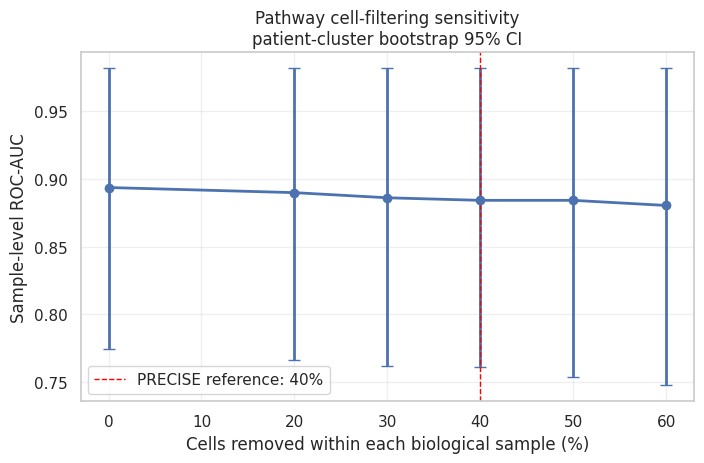

,fraction_cells_removed,sample_auc,patient_bootstrap_mean_auc,ci_lower,ci_upper,mean_cells_kept
0,0.0,0.7173,0.7276,0.5065,0.9271,339.3958
1,0.2,0.7154,0.7256,0.5064,0.9268,271.9792
2,0.3,0.7135,0.7232,0.5065,0.9228,238.0833
3,0.4,0.7211,0.7312,0.5138,0.9351,204.0208
4,0.5,0.7116,0.7221,0.5047,0.9195,170.0000
5,0.6,0.7211,0.7308,0.5097,0.9200,136.2500


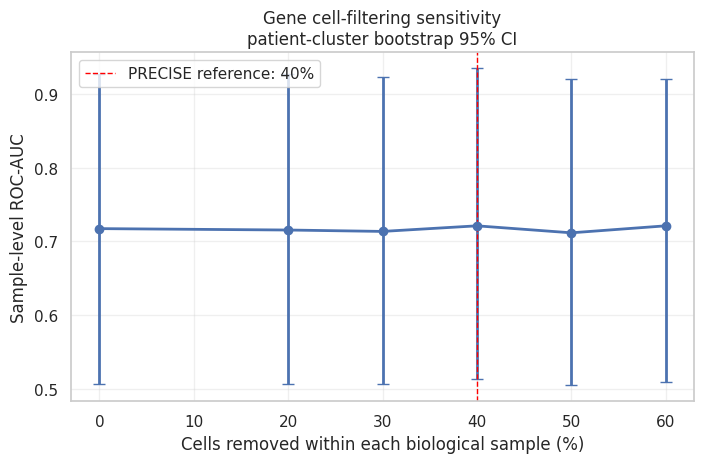

,fraction_cells_removed,sample_auc,patient_bootstrap_mean_auc,ci_lower,ci_upper,mean_cells_kept
0,0.0,0.8008,0.8070,0.6648,0.9420,339.3958
1,0.2,0.7970,0.8029,0.6593,0.9381,271.9792
2,0.3,0.7989,0.8049,0.6617,0.9384,238.0833
3,0.4,0.7970,0.8027,0.6625,0.9385,204.0208
4,0.5,0.7970,0.8027,0.6625,0.9385,170.0000
5,0.6,0.8046,0.8103,0.6775,0.9415,136.2500


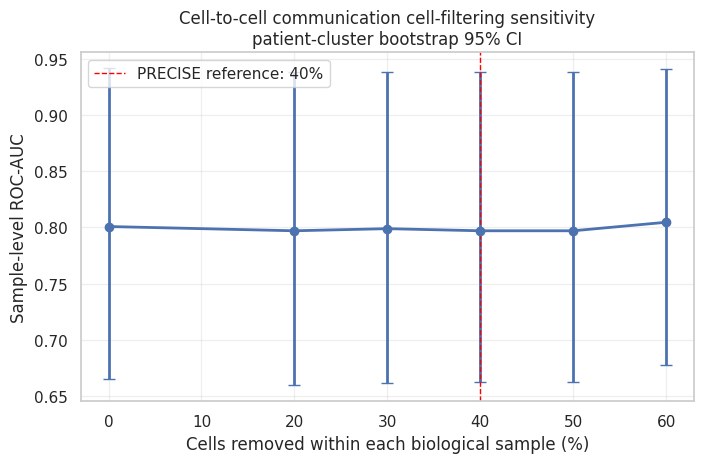

In [16]:
def patient_cluster_bootstrap_auc(data, score_column, n_iterations=BOOTSTRAP_ITERS):
    rng = np.random.default_rng(SEED)
    patient_ids = data['patient_id'].astype(str).unique()
    aucs = []
    for _ in range(n_iterations):
        sampled_patients = rng.choice(patient_ids, size=len(patient_ids), replace=True)
        pieces = []
        for draw_index, patient_id in enumerate(sampled_patients):
            part = data[data['patient_id'].astype(str) == patient_id].copy()
            part['_bootstrap_patient'] = f'{draw_index}_{patient_id}'
            pieces.append(part)
        bootstrap_data = pd.concat(pieces, ignore_index=True)
        if bootstrap_data['true_label'].nunique() < 2:
            continue
        aucs.append(
            roc_auc_score(bootstrap_data['true_label'], bootstrap_data[score_column])
        )
    if not aucs:
        return np.nan, np.nan, np.nan
    return (
        float(np.mean(aucs)),
        float(np.percentile(aucs, 2.5)),
        float(np.percentile(aucs, 97.5)),
    )


def run_cell_filtering_sensitivity(prediction_result):
    tag = prediction_result['tag']
    cells = prediction_result['cell_predictions'].copy()
    cells['informativeness'] = np.abs(cells['cell_probability'] - 0.5)
    rows = []

    for removed_fraction in RL_THRESHOLDS:
        filtered_samples = []
        for sample_id, group in cells.groupby('sample_id'):
            keep_count = max(1, int(np.ceil(len(group) * (1.0 - removed_fraction))))
            kept = group.sort_values('informativeness', ascending=False).head(keep_count)
            filtered_samples.append({
                'sample_id': str(sample_id),
                'patient_id': str(group['patient_id'].iloc[0]),
                'true_label': int(group['true_label'].iloc[0]),
                'filtered_score': float(kept['cell_probability'].mean()),
                'n_cells_original': len(group),
                'n_cells_kept': len(kept),
            })

        filtered = pd.DataFrame(filtered_samples)
        auc_value = roc_auc_score(filtered['true_label'], filtered['filtered_score'])
        bootstrap_mean, ci_lower, ci_upper = patient_cluster_bootstrap_auc(
            filtered, 'filtered_score'
        )
        rows.append({
            'fraction_cells_removed': removed_fraction,
            'sample_auc': auc_value,
            'patient_bootstrap_mean_auc': bootstrap_mean,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'mean_cells_kept': filtered['n_cells_kept'].mean(),
        })

    results = pd.DataFrame(rows)
    results.to_csv(
        OUTPUT_DIR / f'taskD_{tag}_cell_filtering_patient_bootstrap.csv',
        index=False
    )
    display(results.round(4))

    x_values = 100 * results['fraction_cells_removed']
    y_values = results['sample_auc']
    lower_error = np.maximum(0, y_values - results['ci_lower'])
    upper_error = np.maximum(0, results['ci_upper'] - y_values)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.errorbar(
        x_values, y_values, yerr=[lower_error, upper_error],
        marker='o', capsize=4, linewidth=2
    )
    ax.axvline(40, color='red', linestyle='--', linewidth=1,
               label='PRECISE reference: 40%')
    ax.set_xlabel('Cells removed within each biological sample (%)')
    ax.set_ylabel('Sample-level ROC-AUC')
    ax.set_title(
        f'{representation_label(tag)} cell-filtering sensitivity\n'
        'patient-cluster bootstrap 95% CI'
    )
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f'taskD_{tag}_cell_filtering_sensitivity.png',
        dpi=180, bbox_inches='tight'
    )
    plt.show()
    return results


pathway_filtering = run_cell_filtering_sensitivity(pathway_predictions)
gene_filtering = run_cell_filtering_sensitivity(gene_predictions)
celltocell_filtering = run_cell_filtering_sensitivity(celltocell_predictions)

**Comment:** This is a `cell-filtering sensitivity diagnostic`, not a reproduction of the paper's reinforcement-learning procedure. The analysis tests whether removing cells that are uncertain according to our fitted classifiers materially changes sample-level discrimination. Overlapping confidence intervals should be discussed cautiously and do not establish that one threshold is definitively superior.

---
# 14. Optional Harmony Patient-Effect Diagnostic

Single-cell measurements can contain both technical variation and genuine patient-specific biology. In this dataset, `patient_id` is biological identity and not a purely technical batch label. Therefore, Harmony is used only as a **descriptive patient-effect diagnostic** and not as a preprocessing step for Task C.

The diagnostic uses:

- a patient-balanced subsample of cells;
- the 2,000 highest-variance genes;
- 20 principal components;
- identical before/after axis limits;
- patient silhouette, same-patient neighbour fraction, patient-neighbour entropy, and response silhouette.

Reduced patient separation after Harmony indicates that the embedding contains less patient-associated structure. It must not be described as proof that all technical batch effects were removed, and the corrected embedding is not used to retrain or reevaluate any of the three classifiers.

2026-09-11 18:47:11,841 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-11 18:47:11,847 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-11 18:47:11,852 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-11 18:47:11,859 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-11 18:47:11,864 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-11 18:47:11,869 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-11 18:47:11,872 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-11 18:47:11,876 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-11 18:47:11,882 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-11 18:47:11,889 - harmonypy - INFO -     theta: [2. 2. 2

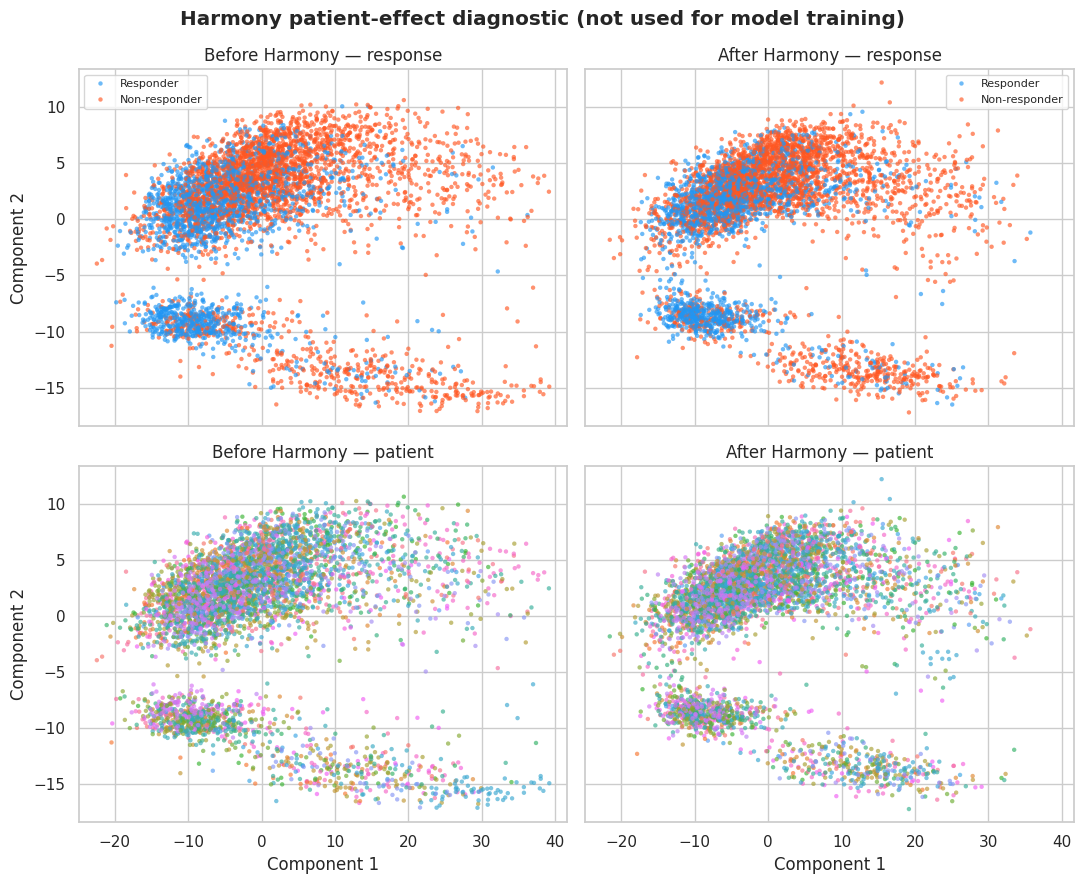

,stage,n_cells,n_patients,n_high_variance_genes,patient_silhouette,same_patient_neighbor_fraction,normalized_patient_neighbor_entropy,response_silhouette
0,Before Harmony,4800,32,2000,-0.0911,0.3168,0.5759,0.0378
1,After Harmony,4800,32,2000,-0.1449,0.0586,0.8400,0.0275


In [17]:
def sparse_feature_variance(matrix):
    if sp.issparse(matrix):
        mean = np.asarray(matrix.mean(axis=0)).ravel()
        mean_square = np.asarray(matrix.power(2).mean(axis=0)).ravel()
        return np.maximum(mean_square - mean ** 2, 0)
    return np.var(np.asarray(matrix), axis=0)


def normalized_neighbor_entropy(labels, neighbor_indices):
    labels = np.asarray(labels).astype(str)
    entropies = []
    maximum_entropy = np.log(neighbor_indices.shape[1])
    for neighbors in neighbor_indices:
        _, counts = np.unique(labels[neighbors], return_counts=True)
        probabilities = counts / counts.sum()
        entropy = -np.sum(probabilities * np.log(probabilities + 1e-12))
        entropies.append(entropy / maximum_entropy if maximum_entropy > 0 else 0)
    return float(np.mean(entropies))


def embedding_diagnostics(embedding, patient_labels, response_labels, k=15):
    neighbor_count = min(k + 1, len(embedding))
    neighbors = NearestNeighbors(n_neighbors=neighbor_count).fit(embedding)
    # Supplying the training embedding explicitly includes each cell itself as
    # the nearest point; remove that first column to retain exactly k neighbours.
    neighbor_indices = neighbors.kneighbors(
        embedding, n_neighbors=neighbor_count, return_distance=False
    )[:, 1:]
    patient_labels = np.asarray(patient_labels).astype(str)
    response_labels = np.asarray(response_labels).astype(str)

    same_patient = np.mean(
        patient_labels[neighbor_indices] == patient_labels[:, None]
    )
    patient_entropy = normalized_neighbor_entropy(patient_labels, neighbor_indices)
    silhouette_sample_size = min(2000, len(embedding))
    patient_silhouette = silhouette_score(
        embedding, patient_labels,
        sample_size=silhouette_sample_size,
        random_state=SEED,
    )
    response_silhouette = silhouette_score(
        embedding, response_labels,
        sample_size=silhouette_sample_size,
        random_state=SEED,
    )
    return {
        'patient_silhouette': float(patient_silhouette),
        'same_patient_neighbor_fraction': float(same_patient),
        'normalized_patient_neighbor_entropy': float(patient_entropy),
        'response_silhouette': float(response_silhouette),
    }


def run_harmony_patient_diagnostic(adata_object):
    rng = np.random.default_rng(SEED)
    all_indices = np.arange(adata_object.n_obs)
    patient_values = adata_object.obs['patient_id'].astype(str).to_numpy()

    # Balanced diagnostic: at most 150 cells from each patient.
    selected = []
    for patient in np.unique(patient_values):
        candidates = all_indices[patient_values == patient]
        selected.extend(rng.choice(candidates, size=min(150, len(candidates)), replace=False))
    selected = np.sort(np.asarray(selected, dtype=int))
    diagnostic = adata_object[selected].copy()

    # Use the 2,000 highest-variance genes rather than scaling every retained gene.
    variances = sparse_feature_variance(diagnostic.X)
    n_hvg = min(2000, diagnostic.n_vars)
    top_gene_indices = np.argsort(variances)[::-1][:n_hvg]
    expression = diagnostic.X[:, top_gene_indices]
    if sp.issparse(expression):
        expression = expression.toarray()
    expression = StandardScaler().fit_transform(np.asarray(expression, dtype=np.float32))

    n_components = min(20, expression.shape[0] - 1, expression.shape[1])
    before = PCA(n_components=n_components, random_state=SEED).fit_transform(expression)

    metadata = diagnostic.obs[['patient_id', 'response_label']].copy()
    metadata['patient_id'] = metadata['patient_id'].astype(str)
    metadata['response_label'] = metadata['response_label'].astype(str)

    harmony_output = hm.run_harmony(
        before, metadata, vars_use=['patient_id'], random_state=SEED
    )
    after = np.asarray(harmony_output.Z_corr)
    if after.shape == before.T.shape:
        after = after.T
    if after.shape != before.shape:
        raise ValueError(f'Unexpected Harmony output shape: {after.shape}; expected {before.shape}.')

    metrics_before = embedding_diagnostics(
        before, metadata['patient_id'], metadata['response_label']
    )
    metrics_after = embedding_diagnostics(
        after, metadata['patient_id'], metadata['response_label']
    )
    metrics = pd.DataFrame([
        {'stage': 'Before Harmony', **metrics_before},
        {'stage': 'After Harmony', **metrics_after},
    ])
    metrics.insert(1, 'n_cells', len(diagnostic))
    metrics.insert(2, 'n_patients', metadata['patient_id'].nunique())
    metrics.insert(3, 'n_high_variance_genes', n_hvg)
    metrics.to_csv(OUTPUT_DIR / 'taskD_harmony_patient_effect_metrics.csv', index=False)

    # Identical axes for honest before/after visual comparison.
    combined_x = np.concatenate([before[:, 0], after[:, 0]])
    combined_y = np.concatenate([before[:, 1], after[:, 1]])
    x_padding = 0.04 * max(np.ptp(combined_x), 1)
    y_padding = 0.04 * max(np.ptp(combined_y), 1)
    x_limits = (combined_x.min() - x_padding, combined_x.max() + x_padding)
    y_limits = (combined_y.min() - y_padding, combined_y.max() + y_padding)

    response_palette = {'Responder': '#2196F3', 'Non-responder': '#FF5722'}
    patients = sorted(metadata['patient_id'].unique())
    patient_colors = dict(zip(patients, sns.color_palette('husl', len(patients))))

    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
    specifications = [
        (axes[0, 0], before, 'response_label', 'Before Harmony — response'),
        (axes[0, 1], after, 'response_label', 'After Harmony — response'),
        (axes[1, 0], before, 'patient_id', 'Before Harmony — patient'),
        (axes[1, 1], after, 'patient_id', 'After Harmony — patient'),
    ]
    for axis, embedding, color_column, title in specifications:
        frame = pd.DataFrame({
            'Component 1': embedding[:, 0],
            'Component 2': embedding[:, 1],
            color_column: metadata[color_column].to_numpy(),
        })
        palette = response_palette if color_column == 'response_label' else patient_colors
        sns.scatterplot(
            data=frame, x='Component 1', y='Component 2', hue=color_column,
            palette=palette, s=10, alpha=0.65, linewidth=0,
            legend=(color_column == 'response_label'), ax=axis,
        )
        axis.set_title(title)
        axis.set_xlim(x_limits)
        axis.set_ylim(y_limits)
        if color_column == 'response_label':
            axis.legend(fontsize=8, title=None)
    fig.suptitle('Harmony patient-effect diagnostic (not used for model training)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'taskD_harmony_patient_effect_diagnostic.png', dpi=180, bbox_inches='tight')
    plt.show()

    display(metrics.round(4))
    return metrics


harmony_metrics = run_harmony_patient_diagnostic(adata)

---
# 15. Export Compact Task D Summary

The final table compares the three representations using their original held-out sample predictions and corrected explainability summaries. All generated filenames contain a `taskD_gene`, `taskD_pathway`, `taskD_celltocell`, or `taskD_harmony` prefix.

The exported files can be used directly when preparing the Results section, while the notebook outputs provide the full analysis trail.

In [18]:
comparison = pd.DataFrame([
    {
        'representation': 'Pathways',
        'model': pathway_bundle['best_model_name'],
        'sample_ROC_AUC': pathway_performance['auc'],
        'average_precision': pathway_performance['average_precision'],
        'misclassified_samples_at_0.5': len(pathway_errors),
        'corrected_top_feature': pathway_explanations['summary'].iloc[0]['feature'],
        'top_feature_selection_frequency': pathway_explanations['summary'].iloc[0]['selection_frequency'],
    },
    {
        'representation': 'Genes',
        'model': gene_bundle['best_model_name'],
        'sample_ROC_AUC': gene_performance['auc'],
        'average_precision': gene_performance['average_precision'],
        'misclassified_samples_at_0.5': len(gene_errors),
        'corrected_top_feature': gene_explanations['summary'].iloc[0]['feature'],
        'top_feature_selection_frequency': gene_explanations['summary'].iloc[0]['selection_frequency'],
    },
    {
        'representation': 'Cell-to-cell communication',
        'model': celltocell_bundle['best_model_name'],
        'sample_ROC_AUC': celltocell_performance['auc'],
        'average_precision': celltocell_performance['average_precision'],
        'misclassified_samples_at_0.5': len(celltocell_errors),
        'corrected_top_feature': celltocell_explanations['summary'].iloc[0]['feature'],
        'top_feature_selection_frequency': celltocell_explanations['summary'].iloc[0]['selection_frequency'],
    },
])
comparison.to_csv(OUTPUT_DIR / 'taskD_gene_pathway_celltocell_summary.csv', index=False)
display(comparison.round(4))

print('\nMain output location:', OUTPUT_DIR)
print('Main figure location:', FIGURES_DIR)

,representation,model,sample_ROC_AUC,average_precision,misclassified_samples_at_0.5,corrected_top_feature,top_feature_selection_frequency
0,Pathways,LogisticRegression,0.8937,0.8605,8,PROGENy_JAK-STAT,1.0
1,Genes,XGBoost,0.7173,0.5604,10,IFI6,1.0
2,Cell-to-cell communication,RandomForest,0.8008,0.6373,10,CCC_Sender_CCL5_to_CCR1,1.0



Main output location: /content/drive/MyDrive/TaskD_outputs
Main figure location: /content/drive/MyDrive/TaskD_figures
